# Preprocessing

-Preprocess the data for clustering (e.g., feature selection, normalization).

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
import random
import numpy as np
from sklearn.metrics import pairwise_distances_argmin_min
from sklearn.metrics import pairwise_distances
from sklearn.linear_model import RANSACRegressor, LinearRegression

Columns: ['Year', 'District', 'Code', 'Location', 'Robbery', 'Street_robbery', 'Injury', 'Agg_assault', 'Threat', 'Theft', 'Car', 'From_car', 'Bike', 'Burglary', 'Fire', 'Arson', 'Damage', 'Graffiti', 'Drugs', 'Local']

Sample Data:


,Year,District,Code,Location,Robbery,Street_robbery,Injury,Agg_assault,Threat,Theft,Car,From_car,Bike,Burglary,Fire,Arson,Damage,Graffiti,Drugs,Local
0,2012,Mitte,10111,Tiergarten Süd,70,46,586,194,118,2263,18,328,120,68,16,4,273,26,171,1032
1,2012,Mitte,10112,Regierungsviertel,65,29,474,123,142,3203,10,307,170,37,10,4,380,124,98,870
2,2012,Mitte,10113,Alexanderplatz,242,136,1541,454,304,8988,81,792,822,275,49,27,1538,522,435,3108
3,2012,Mitte,10114,Brunnenstraße Süd,52,25,254,60,66,1916,86,192,396,131,14,5,428,122,213,752
4,2012,Mitte,10221,Moabit West,130,51,629,185,199,2470,94,410,325,161,42,22,516,64,259,1403


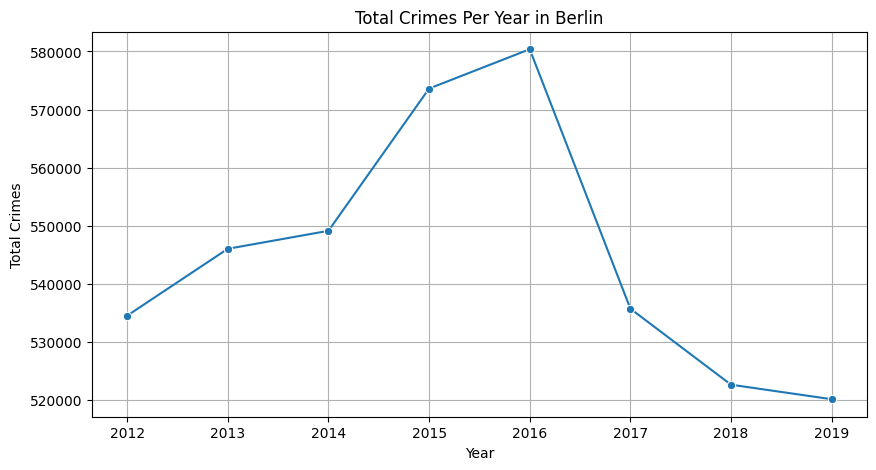

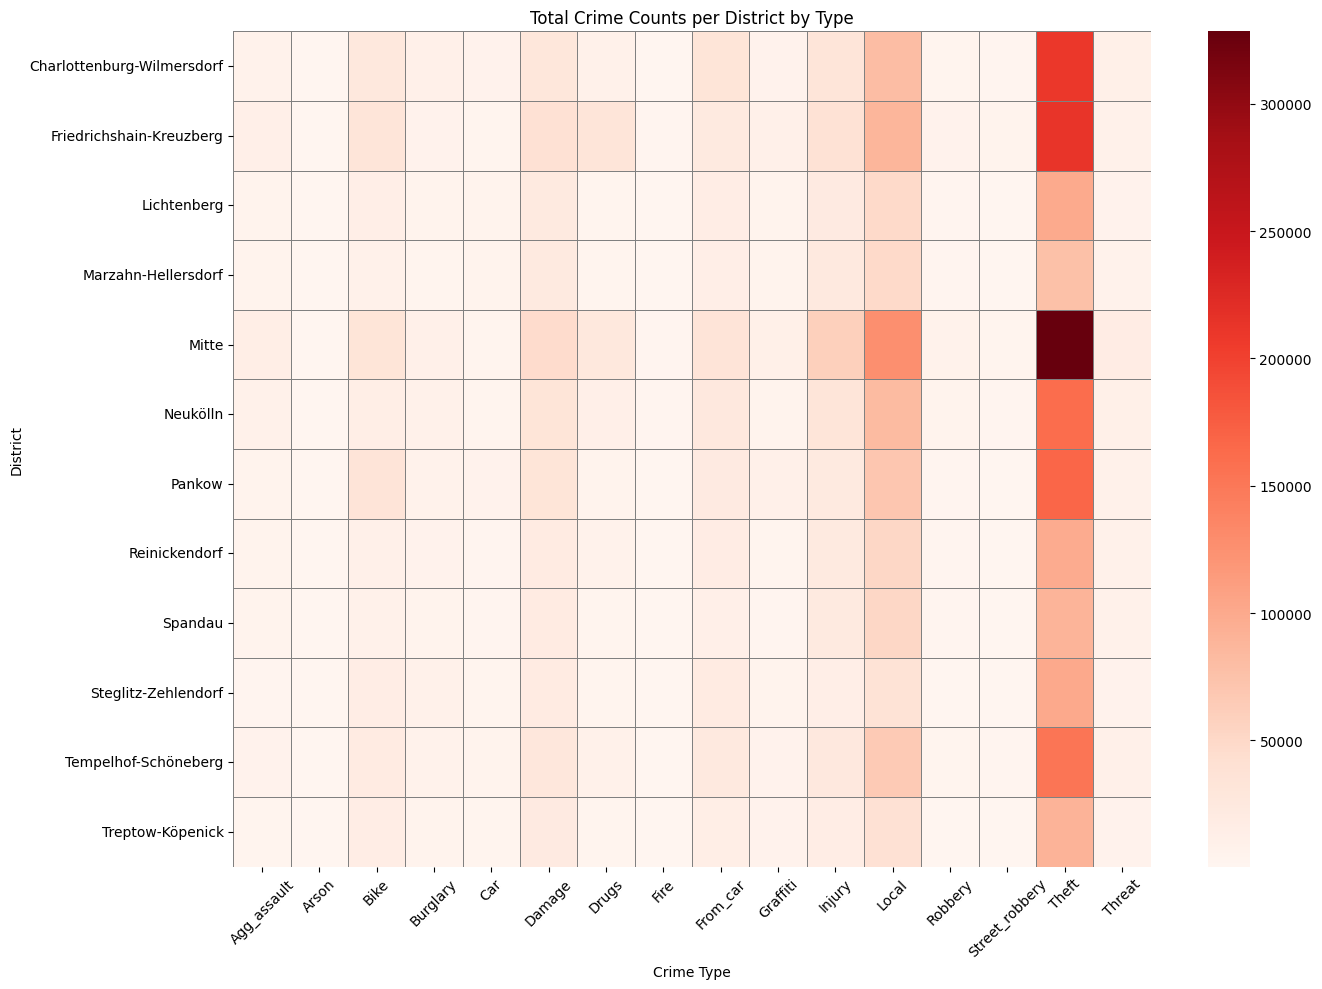

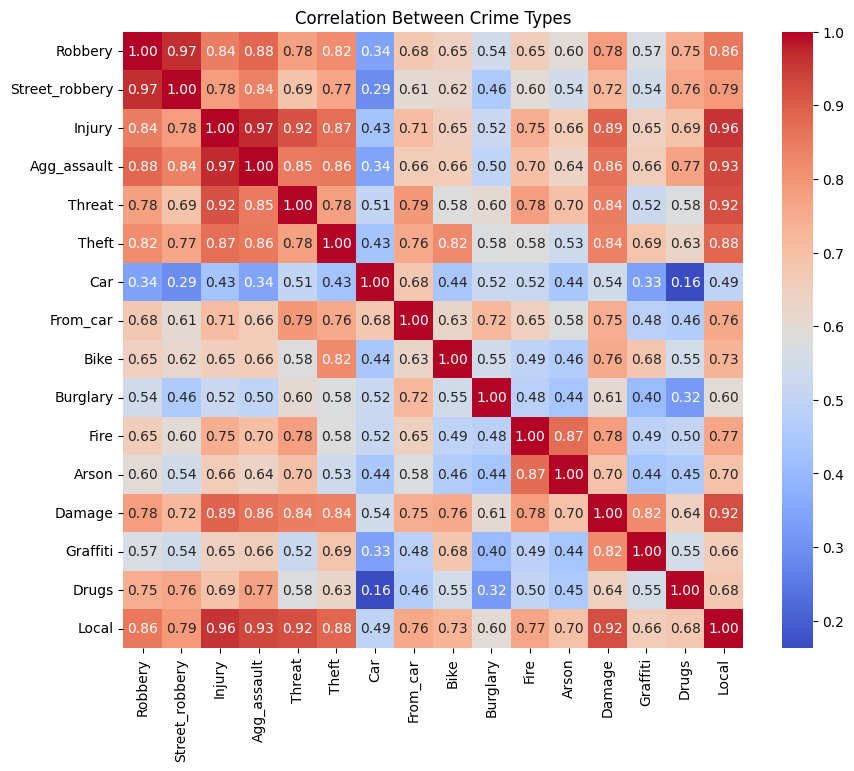

In [3]:
# Unzip the dataset


# Load the dataset
df = pd.read_csv("Berlin_crimes.csv")

# Display initial structure
print("Columns:", df.columns.tolist())
print("\nSample Data:")
display(df.head())

# Step 1: Melt the dataset to long format for easier analysis
crime_types = ['Robbery', 'Street_robbery', 'Injury', 'Agg_assault', 'Threat',
               'Theft', 'Car', 'From_car', 'Bike', 'Burglary', 'Fire', 'Arson',
               'Damage', 'Graffiti', 'Drugs', 'Local']

df_melted = df.melt(id_vars=['Year', 'District', 'Code', 'Location'],
                    value_vars=crime_types,
                    var_name='Crime_Type', value_name='Count')

# Step 2: Total Crimes per Year
yearly_totals = df_melted.groupby('Year')['Count'].sum().reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly_totals, x='Year', y='Count', marker='o')
plt.title('Total Crimes Per Year in Berlin')
plt.ylabel('Total Crimes')
plt.grid(True)
plt.show()

# Step 3: District Heatmap (sum over all years)
district_totals = df_melted.groupby(['District', 'Crime_Type'])['Count'].sum().reset_index()
pivot = district_totals.pivot(index='District', columns='Crime_Type', values='Count').fillna(0)

plt.figure(figsize=(14, 10))
sns.heatmap(pivot, cmap="Reds", linewidths=0.5, linecolor='gray')
plt.title('Total Crime Counts per District by Type')
plt.ylabel('District')
plt.xlabel('Crime Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 4: Correlation Heatmap across crime types (aggregated over all districts and years)
correlation_df = df[crime_types].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_df, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Crime Types')
plt.show()


In [4]:
latex_code = df.iloc[:3, :8].to_latex(index=False)  # index=False if you don't want the index column
print(latex_code)


\begin{tabular}{rlrlrrrr}
\toprule
Year & District & Code & Location & Robbery & Street_robbery & Injury & Agg_assault \\
\midrule
2012 & Mitte & 10111 & Tiergarten Süd & 70 & 46 & 586 & 194 \\
2012 & Mitte & 10112 & Regierungsviertel & 65 & 29 & 474 & 123 \\
2012 & Mitte & 10113 & Alexanderplatz & 242 & 136 & 1541 & 454 \\
\bottomrule
\end{tabular}



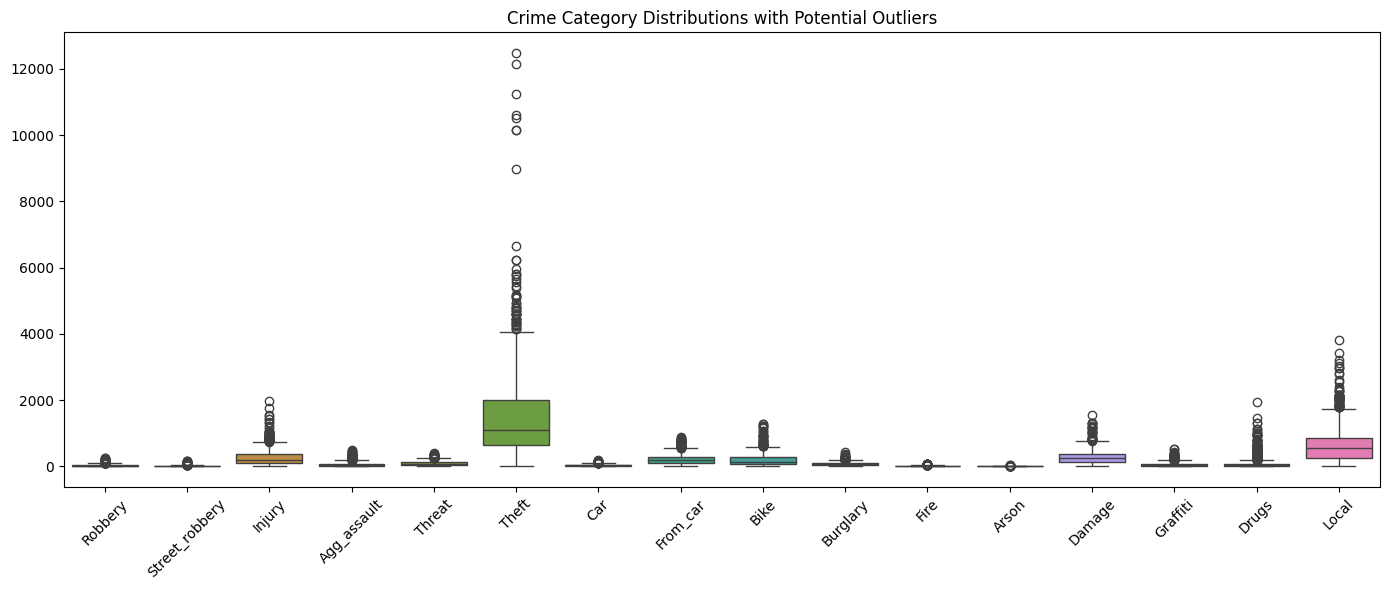

In [5]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[crime_types])
plt.title("Crime Category Distributions with Potential Outliers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("boxplot.png")
plt.show()

# Implementation

Implement the following robust methods from the paper:
* Trimmed K-Means
* T-Clust (both k-means and GMM variants)
* Trimmed K-Medoids
* Robust Clusterwise Linear Regression
* Robust Linear Grouping

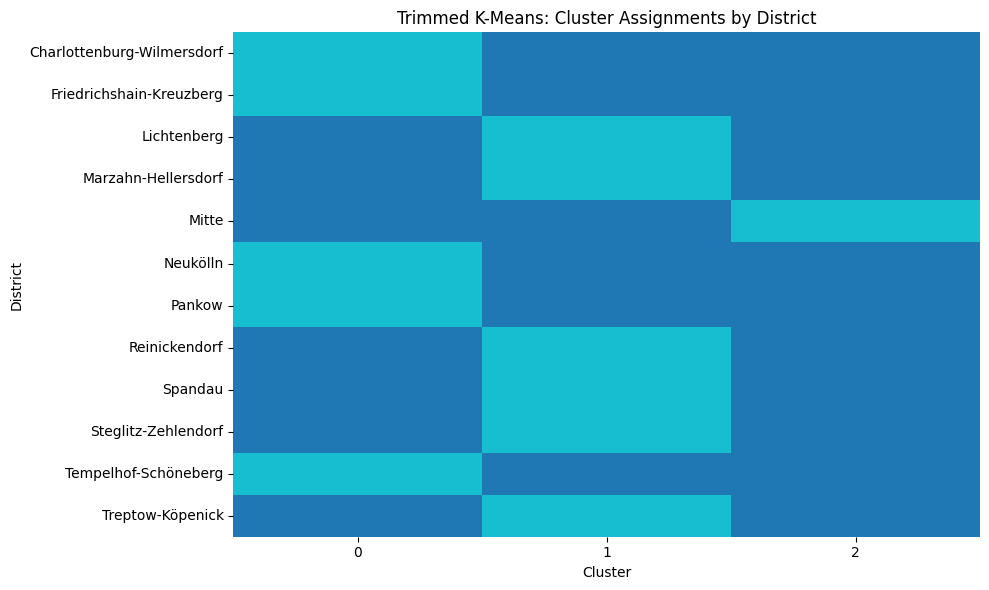

In [6]:
# Use the pivot data where rows = Districts, columns = Crime Types, values = total crimes
crime_matrix = pivot.copy()

# Step 1: Implement Trimmed K-Means
def trimmed_kmeans(X, n_clusters=3, alpha=0.1, max_iter=100, random_state=42):
    """
    Trimmed K-Means: removes top alpha fraction of farthest points at each iteration
    """
    np.random.seed(random_state)
    X = X.values
    n_samples = X.shape[0]
    n_trim = int(alpha * n_samples)

    # Initialize KMeans
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, max_iter=1, random_state=random_state)

    for _ in range(max_iter):
        # Fit KMeans
        kmeans.fit(X)
        labels, distances = pairwise_distances_argmin_min(X, kmeans.cluster_centers_)

        # Trim top alpha fraction of farthest distances
        trim_indices = np.argsort(distances)[-n_trim:]
        keep_mask = np.ones(n_samples, dtype=bool)
        keep_mask[trim_indices] = False

        # Refit on trimmed data
        kmeans = KMeans(n_clusters=n_clusters, n_init=1, max_iter=1, random_state=random_state)
        kmeans.fit(X[keep_mask])

    final_labels, final_distances = pairwise_distances_argmin_min(X, kmeans.cluster_centers_)
    return final_labels, keep_mask, kmeans.cluster_centers_

# Apply Trimmed K-Means
labels_trimmed, keep_mask_trimmed, centers_trimmed = trimmed_kmeans(crime_matrix, n_clusters=3, alpha=0.1)

# Visualize cluster assignments for districts
clustered_df = pd.DataFrame({
    'District': crime_matrix.index,
    'Cluster': labels_trimmed,
    'Trimmed': ~keep_mask_trimmed
}).set_index('District')

plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(clustered_df.index, clustered_df['Cluster']), cmap='tab10', cbar=False)
plt.title("Trimmed K-Means: Cluster Assignments by District")
plt.xlabel("Cluster")
plt.ylabel("District")
plt.tight_layout()
plt.show()


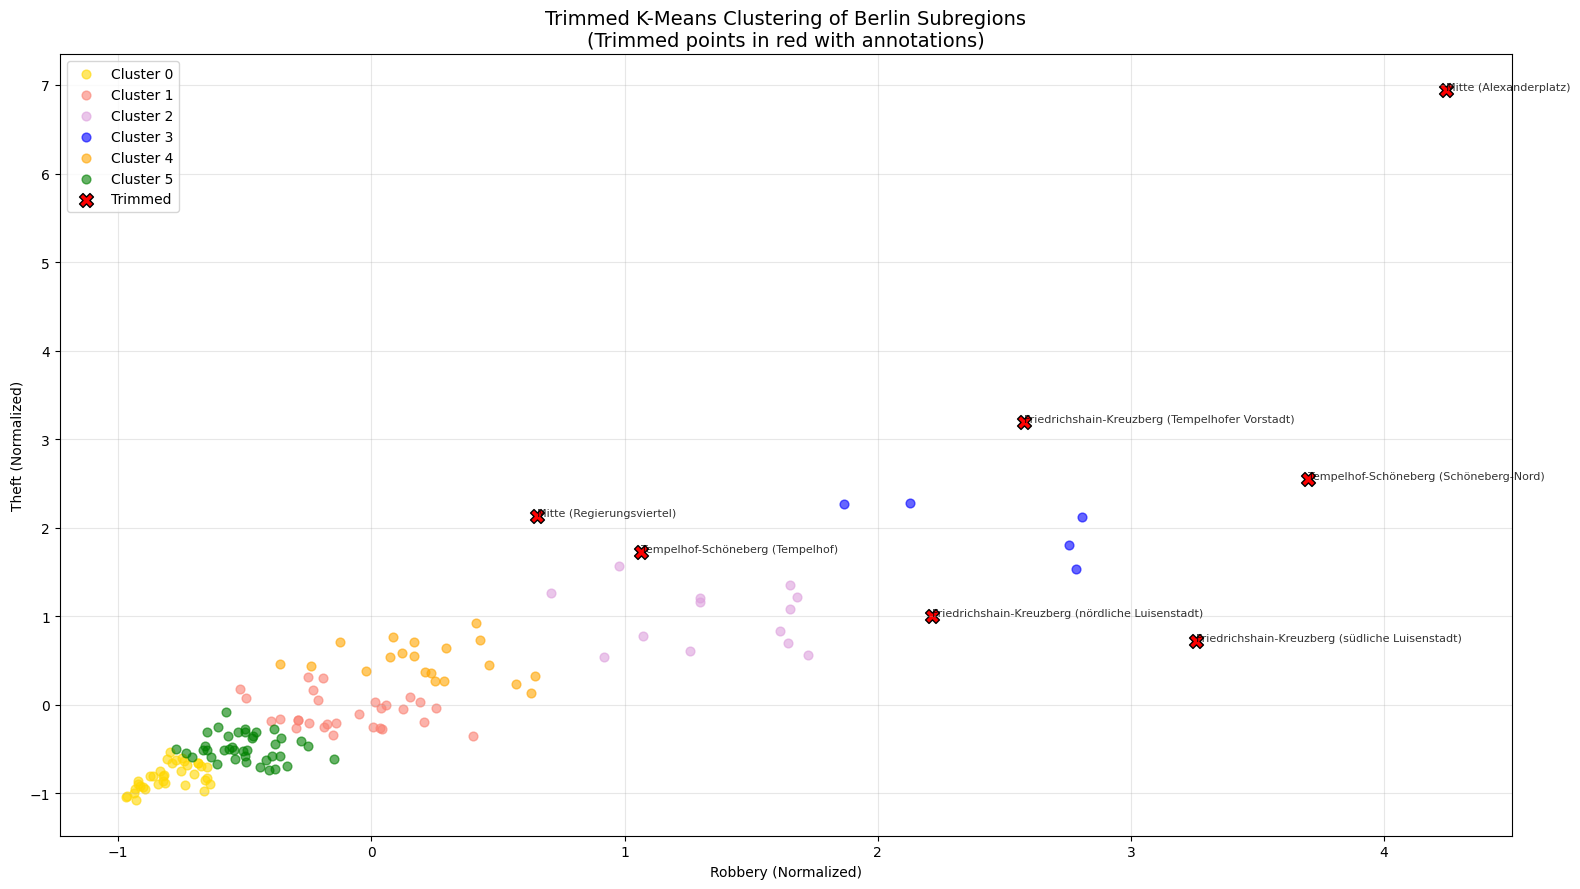

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import random
from sklearn.mixture import GaussianMixture
from sklearn.metrics import pairwise_distances
import seaborn as sns

# Load and normalize the data
df = pd.read_csv("Berlin_crimes.csv")

features = ['Robbery', 'Theft']


# Step 1: Group raw (unscaled) data by region
grouped = df.groupby(['District', 'Location'])[features].mean().reset_index()


# Step 2: Standardize only Robbery and Theft columns
scaler = StandardScaler()
grouped_scaled = grouped.copy()
grouped_scaled[features] = scaler.fit_transform(grouped[features])
grouped=grouped_scaled

# Step 3: Extract X for clustering
X = grouped_scaled[features].values

# --- Trimmed KMeans implementation ---
def trimmed_kmeans(X, n_clusters=3, alpha=0.1, n_init=20, max_iter=100):
    best_inertia = np.inf
    best_centroids = None
    best_labels = None
    best_trimmed_idx = None

    n_trim = int(alpha * len(X))

    for _ in range(n_init):
        centroids = X[np.random.choice(len(X), n_clusters, replace=False)]
        for _ in range(max_iter):
            labels, distances = pairwise_distances_argmin_min(X, centroids)
            sorted_idx = np.argsort(distances)
            keep_idx = sorted_idx[:-n_trim]

            new_centroids = []
            for k in range(n_clusters):
                members = X[keep_idx][labels[keep_idx] == k]
                if len(members) > 0:
                    new_centroids.append(members.mean(axis=0))
                else:
                    new_centroids.append(X[np.random.choice(len(X))])
            centroids = np.vstack(new_centroids)

        labels, distances = pairwise_distances_argmin_min(X, centroids)
        trimmed_inertia = np.sum(np.sort(distances)[:-n_trim]**2)
        if trimmed_inertia < best_inertia:
            best_inertia = trimmed_inertia
            best_centroids = centroids
            best_labels = labels
            best_trimmed_idx = sorted_idx[-n_trim:]

    # Assign -1 to trimmed outliers
    best_labels[best_trimmed_idx] = -1

    return best_labels, best_trimmed_idx, best_centroids

# Run trimmed k-means
labels_km, trimmed_km, model_km = trimmed_kmeans(X, n_clusters=6, alpha=0.05)

# Add results to DataFrame
grouped['Cluster'] = labels_km
grouped['Trimmed'] = False
grouped.loc[trimmed_km, 'Trimmed'] = True

# Plot: Robbery vs Theft with Trimming Labels
plt.figure(figsize=(16, 9))

colors = ['gold', 'salmon', 'plum',"blue","orange","green"]
for c in range(6):
    subset = grouped[(grouped['Cluster'] == c) & (~grouped['Trimmed'])]
    plt.scatter(subset['Robbery'], subset['Theft'], label=f"Cluster {c}", alpha=0.6, s=40, color=colors[c])

# Trimmed points
trimmed_subset = grouped[grouped['Trimmed']]
plt.scatter(trimmed_subset['Robbery'], trimmed_subset['Theft'],
            color='red', marker='X', s=100, label='Trimmed', edgecolor='k')

# Annotations for trimmed points
for _, row in trimmed_subset.iterrows():
    plt.text(row['Robbery'], row['Theft'], f"{row['District']} ({row['Location']})", fontsize=8, alpha=0.8)

plt.title("Trimmed K-Means Clustering of Berlin Subregions\n(Trimmed points in red with annotations)", fontsize=14)
plt.xlabel("Robbery (Normalized)")
plt.ylabel("Theft (Normalized)")
plt.legend()
plt.tight_layout()
plt.grid(alpha=0.3)
#plt.savefig("trimmed_kmeans_clusters.png", dpi=300)
plt.show()


In [9]:
X
n_rows = X.shape[0]
print(n_rows)

150


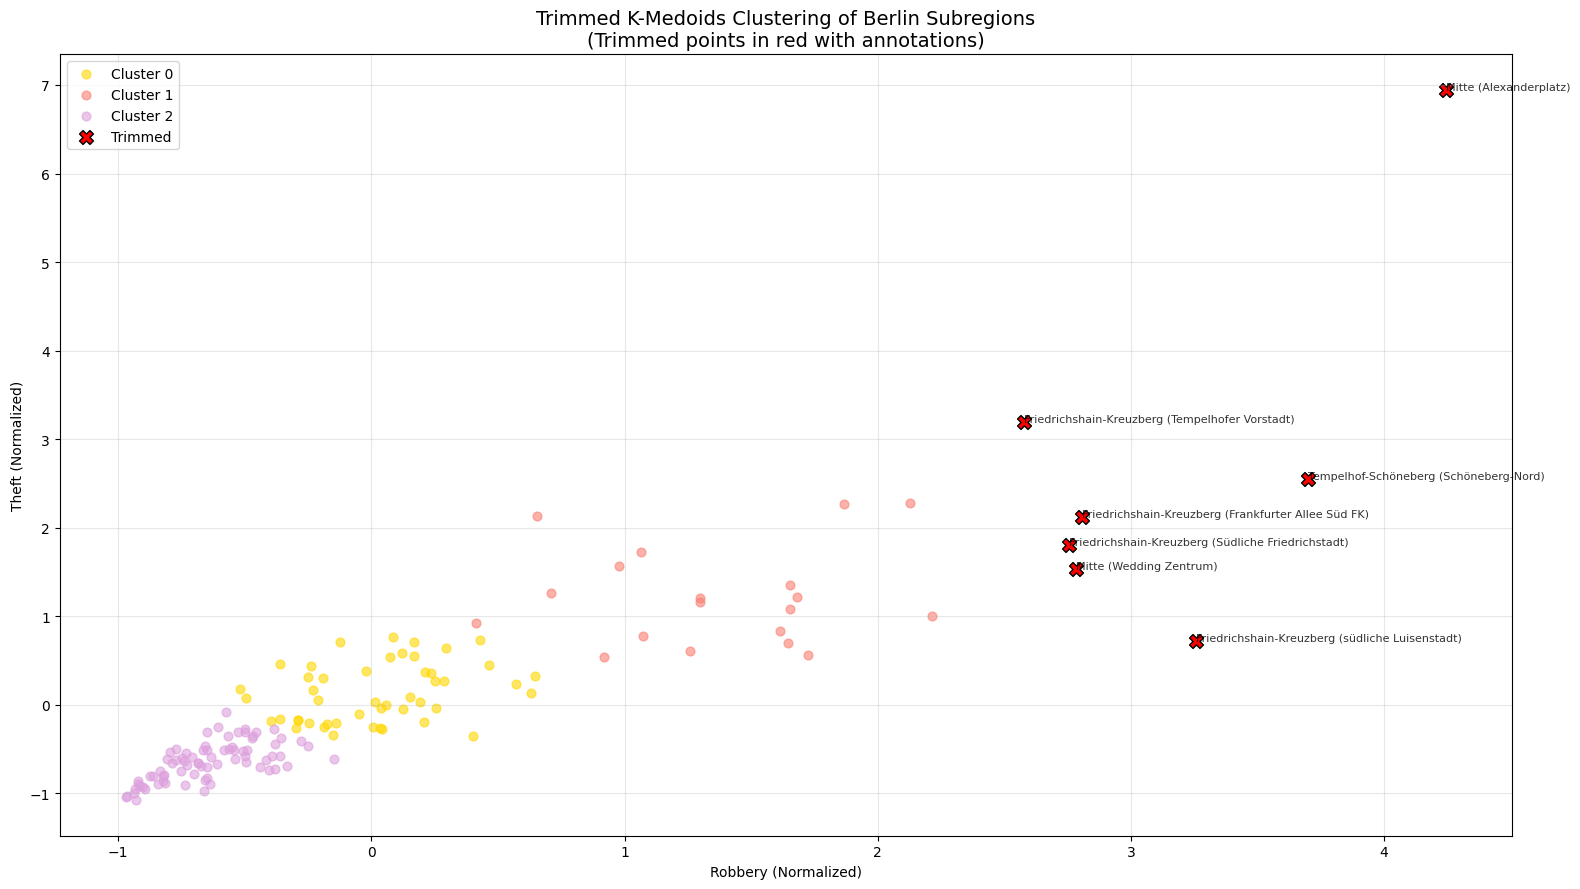

In [7]:
df = pd.read_csv("Berlin_crimes.csv")

features = ['Robbery', 'Theft']


# Step 1: Group raw (unscaled) data by region
grouped = df.groupby(['District', 'Location'])[features].mean().reset_index()


# Step 2: Standardize only Robbery and Theft columns
scaler = StandardScaler()
grouped_scaled = grouped.copy()
grouped_scaled[features] = scaler.fit_transform(grouped[features])
grouped=grouped_scaled

# Step 3: Extract X for clustering
X = grouped_scaled[features].values




def trimmed_kmedoids(X, n_clusters=2, alpha=0.10, max_iter=100,n_init=20, random_state=42):
    
    n_samples = len(X)
    n_trim = int(alpha * n_samples)

    best_labels = None
    best_medoids = None
    best_trim_idx = None
    best_cost = np.inf

    # Initialize medoids randomly from data
    for tt in range(n_init):
        medoid_indices = np.random.choice(n_samples, size=n_clusters, replace=False)
        medoids = X[medoid_indices]

        for _ in range(max_iter):
        # Compute distances from each point to all medoids
            dists = cdist(X, medoids, metric='euclidean')
            min_dists = np.min(dists, axis=1)

        # Trim the farthest points
            trim_idx = np.argsort(min_dists)[-n_trim:]
            keep_mask = np.ones(n_samples, dtype=bool)
            keep_mask[trim_idx] = False

        # Assign labels for only the untrimmed points
            untrimmed_dists = dists[keep_mask]
            labels = np.argmin(untrimmed_dists, axis=1)

            new_medoids = []
            for i in range(n_clusters):
                cluster_points = X[keep_mask][labels == i]
                if len(cluster_points) == 0:
                # If a cluster is empty, reassign a random medoid
                    new_medoids.append(X[np.random.choice(n_samples)])
                    continue
            # Compute total cost of each point being the medoid
                intra_dists = cdist(cluster_points, cluster_points)
                total_cost = np.sum(intra_dists, axis=1)
                best_medoid = cluster_points[np.argmin(total_cost)]
                new_medoids.append(best_medoid)
            new_medoids = np.array(new_medoids)

            if np.allclose(medoids, new_medoids):
                break
            medoids = new_medoids

        """"final_dists = cdist(X, medoids, metric='euclidean')
        mask = np.ones(n_samples, dtype=bool)
        mask[trim_idx] = False
        run_cost = np.sum(np.min(final_dists[mask], axis=1))

        if run_cost < best_cost:
            best_cost = run_cost
            best_medoids = medoids
            best_trim_idx = trim_idx
            best_labels = np.argmin(final_dists, axis=1)
            best_labels[trim_idx] = -1"""

        final_dists = cdist(X, medoids, metric='euclidean')
        min_final_dists = np.min(final_dists, axis=1)
        final_trim_idx = np.argsort(min_final_dists)[-n_trim:] if n_trim > 0 else np.array([], dtype=int)
        mask = np.ones(n_samples, dtype=bool)
        mask[final_trim_idx] = False

        run_cost = np.sum(np.min(final_dists[mask], axis=1))

        if run_cost < best_cost:
            best_cost = run_cost
            best_medoids = medoids
            best_trim_idx = final_trim_idx
            best_labels = np.argmin(final_dists, axis=1)
            if len(best_trim_idx) > 0:
                best_labels[best_trim_idx] = -1       

    return best_labels, best_trim_idx, best_medoids


labels_km, trimmed_km, model_km = trimmed_kmedoids(X, n_clusters=3, alpha=0.05)

# Add results to DataFrame
grouped['Cluster'] = labels_km
grouped['Trimmed'] = False
grouped.loc[trimmed_km, 'Trimmed'] = True

# Plot: Robbery vs Theft with Trimming Labels
plt.figure(figsize=(16, 9))

colors = ['gold', 'salmon', 'plum']
for c in range(3):
    subset = grouped[(grouped['Cluster'] == c) & (~grouped['Trimmed'])]
    plt.scatter(subset['Robbery'], subset['Theft'], label=f"Cluster {c}", alpha=0.6, s=40, color=colors[c])

# Trimmed points
trimmed_subset = grouped[grouped['Trimmed']]
plt.scatter(trimmed_subset['Robbery'], trimmed_subset['Theft'],
            color='red', marker='X', s=100, label='Trimmed', edgecolor='k')

# Annotations for trimmed points
for _, row in trimmed_subset.iterrows():
    plt.text(row['Robbery'], row['Theft'], f"{row['District']} ({row['Location']})", fontsize=8, alpha=0.8)

plt.title("Trimmed K-Medoids Clustering of Berlin Subregions\n(Trimmed points in red with annotations)", fontsize=14)
plt.xlabel("Robbery (Normalized)")
plt.ylabel("Theft (Normalized)")
plt.legend()
plt.tight_layout()
plt.grid(alpha=0.3)
plt.savefig("trimmed_kmedoids_clustering.png", dpi=300)
plt.show()

In [8]:
def t_clust_gmm(X, n_clusters=3, trim_fraction=0.1, max_iter=10, random_state=42):
    """
    Iterative TCLUST: trims fixed α-fraction cumulatively based on log-likelihood.
    Returns labels for untrimmed points and indices of trimmed points.
    """
    np.random.seed(random_state)
    n_samples = X.shape[0]
    total_trim = int(trim_fraction * n_samples)
    trimmed_mask = np.zeros(n_samples, dtype=bool)

    for _ in range(max_iter):
        X_remaining = X[~trimmed_mask]
        if len(X_remaining) <= n_clusters + 1:
            break

        gmm = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=random_state)
        gmm.fit(X_remaining)
        log_likelihood = gmm.score_samples(X_remaining)

        trim_left = total_trim - np.sum(trimmed_mask)
        if trim_left <= 0:
            break

        remaining_idx = np.where(~trimmed_mask)[0]
        trim_now_local_idx = np.argsort(log_likelihood)[:trim_left]
        trim_now_global_idx = remaining_idx[trim_now_local_idx]
        trimmed_mask[trim_now_global_idx] = True

    # Final GMM fit on untrimmed data
    X_clean = X[~trimmed_mask]
    gmm_final = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=random_state)
    gmm_final.fit(X_clean)
    labels_clean = gmm_final.predict(X_clean)

    trimmed_idx = np.where(trimmed_mask)[0]

    return labels_clean, trimmed_idx

def trimmed_kmedoids(X, n_clusters=3, trim_fraction=0.10, max_iter=100,n_init=20, random_state=42):
    
    n_samples = len(X)
    n_trim = int(trim_fraction * n_samples)

    best_labels = None
    best_medoids = None
    best_trim_idx = None
    best_cost = np.inf

    # Initialize medoids randomly from data
    for tt in range(n_init):
        medoid_indices = np.random.choice(n_samples, size=n_clusters, replace=False)
        medoids = X[medoid_indices]

        for _ in range(max_iter):
        # Compute distances from each point to all medoids
            dists = cdist(X, medoids, metric='cityblock')
            min_dists = np.min(dists, axis=1)

        # Trim the farthest points
            trim_idx = np.argsort(min_dists)[-n_trim:]
            keep_mask = np.ones(n_samples, dtype=bool)
            keep_mask[trim_idx] = False

        # Assign labels for only the untrimmed points
            untrimmed_dists = dists[keep_mask]
            labels = np.argmin(untrimmed_dists, axis=1)

            new_medoids = []
            for i in range(n_clusters):
                cluster_points = X[keep_mask][labels == i]
                if len(cluster_points) == 0:
                # If a cluster is empty, reassign a random medoid
                    new_medoids.append(X[np.random.choice(n_samples)])
                    continue
            # Compute total cost of each point being the medoid
                intra_dists = cdist(cluster_points, cluster_points)
                total_cost = np.sum(intra_dists, axis=1)
                best_medoid = cluster_points[np.argmin(total_cost)]
                new_medoids.append(best_medoid)
            new_medoids = np.array(new_medoids)

            if np.allclose(medoids, new_medoids):
                break
            medoids = new_medoids

        final_dists = cdist(X, medoids, metric='cityblock')
        mask = np.ones(n_samples, dtype=bool)
        mask[trim_idx] = False
        run_cost = np.sum(np.min(final_dists[mask], axis=1))

        if run_cost < best_cost:
            best_cost = run_cost
            best_medoids = medoids
            best_trim_idx = trim_idx
            best_labels = np.argmin(final_dists, axis=1)
            best_labels[trim_idx] = -1




    untrimmed_mask = best_labels != -1
    labels_clean = best_labels[untrimmed_mask]
    X_clean = X[untrimmed_mask]

            

    return labels_clean, best_trim_idx, best_medoids

def robust_linear_grouping(X, n_clusters=3, trim_fraction=0.1, random_state=42):
    """
    RLG-lite via PCA (orthogonal distances):
      1) K-means (rough clusters)
      2) Per cluster: PCA (1D subspace) -> orthogonal distances to that line
      3) Trim largest distances
      4) Re-cluster untrimmed points
    Returns:
      final_labels (for untrimmed points only), trim_indices
    """
    X = np.asarray(X)
    n = len(X)

    # Step 1: rough clusters
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state).fit(X)
    cluster_labels = kmeans.labels_

    # Step 2: PCA line per cluster + ORTHOGONAL distances
    residuals = np.zeros(n)
    for c in range(n_clusters):
        idx = (cluster_labels == c)
        if idx.sum() < 2:
            residuals[idx] = np.inf
            continue

        Xc = X[idx]
        mu = Xc.mean(axis=0)                 # line passes through the cluster mean
        Z = Xc - mu
        # first principal direction (unit) via SVD
        _, _, Vt = np.linalg.svd(Z, full_matrices=False)
        v = Vt[0]
        v /= np.linalg.norm(v)

        # orthogonal distance to the line: || (I - vv^T)(x - mu) ||
        proj_orth = Z - np.outer(Z @ v, v)   # component orthogonal to v
        residuals[idx] = np.linalg.norm(proj_orth, axis=1)

    # Step 3: trim top residuals
    n_trim = int(np.floor(trim_fraction * n))
    trim_indices = np.argsort(residuals)[-n_trim:] if n_trim > 0 else np.array([], dtype=int)

    # Step 4: re-cluster untrimmed
    mask = np.ones(n, dtype=bool)
    mask[trim_indices] = False
    X_untrimmed = X[mask]
    final_labels = KMeans(n_clusters=n_clusters, random_state=random_state).fit_predict(X_untrimmed)

    return final_labels, trim_indices

def robust_clusterwise_linear_regression(X, y, n_clusters=3, trim_fraction=0.1):
    from sklearn.cluster import KMeans
    from sklearn.linear_model import LinearRegression

    n = len(X)
    n_trim = int(trim_fraction * n)

    # Step 1: Initial clustering
    km = KMeans(n_clusters=n_clusters, random_state=42)
    labels_all = km.fit_predict(X)

    # Step 2: Calculate residual errors for each point
    errors = np.zeros(n)
    for i in range(n_clusters):
        group_idx = np.where(labels_all == i)[0]
        if len(group_idx) < 2:
            errors[group_idx] = np.inf
            continue
        model = LinearRegression().fit(X[group_idx], y[group_idx])
        preds = model.predict(X[group_idx])
        errors[group_idx] = (y[group_idx] - preds) ** 2

    # Step 3: Trim the top n_trim residuals
    trim_indices = np.argsort(errors)[-n_trim:]
    mask = np.ones(n, dtype=bool)
    mask[trim_indices] = False

    # Step 4: Recluster and fit on untrimmed data
    X_untrimmed = X[mask]
    labels_untrimmed = KMeans(n_clusters=n_clusters, random_state=42).fit_predict(X_untrimmed)

    return labels_untrimmed, trim_indices



In [9]:
def plot_clusters(data, labels, trimmed_indices, title, filename, show_labels=True):
    data = data.copy()

    # Step 1: Flag trimmed rows
    data['Trimmed'] = False
    data.loc[trimmed_indices, 'Trimmed'] = True

    # Step 2: Assign clusters only to non-trimmed rows
    data['Cluster'] = -1
    non_trimmed_mask = ~data['Trimmed']

    if len(labels) == non_trimmed_mask.sum():
        data.loc[non_trimmed_mask, 'Cluster'] = labels
    else:
        raise ValueError("Mismatch between label size and non-trimmed data points.")

    # Step 3: Plot clusters
    plt.figure(figsize=(12, 8))
    colors = ['gold', 'salmon', 'plum', 'lightblue', 'lightgreen', 'orange']

    for c in sorted(data['Cluster'].unique()):
        if c == -1:
            continue
        subset = data[(data['Cluster'] == c) & (~data['Trimmed'])]
        plt.scatter(subset['Robbery'], subset['Theft'],
                    label=f"Cluster {c}", alpha=0.6, s=50, color=colors[c % len(colors)])

    # Step 4: Plot trimmed points
    trimmed_subset = data[data['Trimmed']]
    plt.scatter(trimmed_subset['Robbery'], trimmed_subset['Theft'],
                color='red', marker='X', s=100, label='Trimmed', edgecolor='k')

    # Step 5: Label trimmed with district + subregion
    if show_labels:
        for _, row in trimmed_subset.iterrows():
            plt.text(row['Robbery'], row['Theft'],
                     f"{row['District']} ({row['Location']})", fontsize=7, alpha=0.8)

    plt.title(title, fontsize=13)
    plt.xlabel("Robbery (Normalized)")
    plt.ylabel("Theft (Normalized)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.close()


# Re-run clustering and plotting now that t_clust_gmm is fixed
results = {}

labels_kmed, trimmed_kmed, medoids = trimmed_kmedoids(X)
plot_clusters(grouped.copy(), labels_kmed, trimmed_kmed, "Trimmed K-Medoids Clustering of Berlin Subregions", "./trimmed_kmedoids.png")
results['Trimmed_KMedoids'] = (labels_kmed, trimmed_kmed)

labels_tclust, trimmed_tclust = t_clust_gmm(X, n_clusters=3, trim_fraction=0.1)
plot_clusters(grouped.copy(), labels_tclust, trimmed_tclust,
              "T‑Clust (Trimmed GMM) of Berlin Subregions", "./t_clust.png")
results['TClust_GMM'] = (labels_tclust, trimmed_tclust)


labels_rlg, trimmed_rlg = robust_linear_grouping(X)
plot_clusters(grouped.copy(), labels_rlg, trimmed_rlg, "Robust Linear Grouping of Berlin Subregions", "./robust_linear_grouping.png")
results['Robust_Linear_Grouping'] = (labels_rlg, trimmed_rlg)

y = grouped['Robbery'].values
labels_rclr, trimmed_rclr = robust_clusterwise_linear_regression(X, y)
plot_clusters(grouped.copy(), labels_rclr, trimmed_rclr, "Robust Clusterwise Linear Regression on 'Robbery'", "./robust_clusterwise_lr.png")
results['Robust_Clusterwise_Linear_Regression'] = (labels_rclr, trimmed_rclr)

results_summary = {
    k: {
        'Num Clusters': len(set(v[0])),
        'Trimmed Points': len(v[1])
    } for k, v in results.items()
}
results_summary


{'Trimmed_KMedoids': {'Num Clusters': 3, 'Trimmed Points': 15},
 'TClust_GMM': {'Num Clusters': 3, 'Trimmed Points': 15},
 'Robust_Linear_Grouping': {'Num Clusters': 3, 'Trimmed Points': 15},
 'Robust_Clusterwise_Linear_Regression': {'Num Clusters': 3,
  'Trimmed Points': 15}}

# CLT and C

Demonstrate how the c constraint in T-Clust controls the model’s behavior.

# fixed ctl c

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


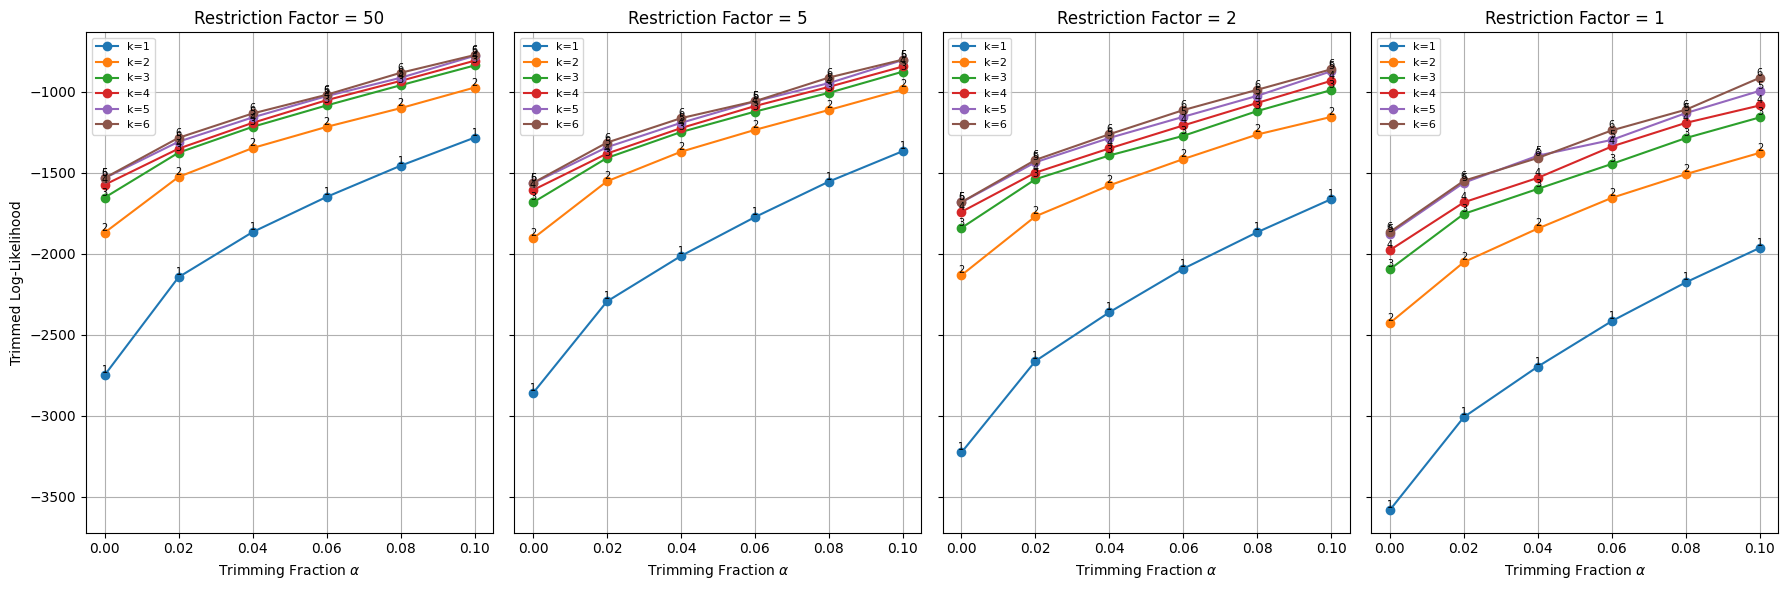

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from numpy.linalg import eigh, inv, cholesky

# Load and normalize the data
df = pd.read_csv("Berlin_crimes.csv")
features = ['Robbery', 'Theft']
X_raw = df[features].dropna().values
X = StandardScaler().fit_transform(X_raw)

# Restriction function
def apply_restriction(covs, c):
    adjusted_covs = []
    for cov in covs:
        eigvals, eigvecs = eigh(cov)
        eigvals = np.clip(eigvals, eigvals.max() / c, eigvals.max())
        adjusted_cov = eigvecs @ np.diag(eigvals) @ eigvecs.T
        adjusted_covs.append(adjusted_cov)
    return np.array(adjusted_covs)

# Trimmed GMM log-likelihood with restriction factor
def tclust_objective(X, k, alpha, c, max_iter=10, random_state=42):
    np.random.seed(random_state)
    n = X.shape[0]
    total_trim = int(alpha * n)
    trimmed_mask = np.zeros(n, dtype=bool)

    for _ in range(max_iter):
        X_clean = X[~trimmed_mask]
        if len(X_clean) <= k + 1:
            break

        gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=random_state)
        gmm.fit(X_clean)

        if c < np.inf:
            gmm.covariances_ = apply_restriction(gmm.covariances_, c)
            gmm.precisions_cholesky_ = cholesky(inv(gmm.covariances_))

        log_likelihoods = gmm.score_samples(X_clean)
        trim_remaining = total_trim - np.sum(trimmed_mask)
        if trim_remaining <= 0:
            break

        global_idx = np.where(~trimmed_mask)[0]
        local_trim = np.argsort(log_likelihoods)[:trim_remaining]
        trim_idx = global_idx[local_trim]
        trimmed_mask[trim_idx] = True

    # Final GMM fit
    X_final = X[~trimmed_mask]
    gmm_final = GaussianMixture(n_components=k, covariance_type='full', random_state=random_state)
    gmm_final.fit(X_final)

    if c < np.inf:
        gmm_final.covariances_ = apply_restriction(gmm_final.covariances_, c)
        gmm_final.precisions_cholesky_ = cholesky(inv(gmm_final.covariances_))

    log_probs = gmm_final.score_samples(X_final)
    return log_probs.sum()

# Parameters
alphas = np.linspace(0, 0.10, 6)
ks = list(range(1, 7))
restriction_factors = [50, 5, 2, 1]
results = {}

# Compute log-likelihoods for each setting
for c in restriction_factors:
    matrix = np.zeros((len(ks), len(alphas)))
    for i, k in enumerate(ks):
        for j, alpha in enumerate(alphas):
            matrix[i, j] = tclust_objective(X, k, alpha, c)
    results[c] = matrix

# Plotting results
fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=True)
for idx, c in enumerate(restriction_factors):
    ax = axes[idx]
    matrix = results[c]
    for i, k in enumerate(ks):
        ax.plot(alphas, matrix[i], marker='o', label=f"k={k}")
        for j, alpha in enumerate(alphas):
            ax.text(alphas[j], matrix[i, j], str(k), fontsize=7, ha='center', va='bottom')
    ax.set_title(f"Restriction Factor = {c}")
    ax.set_xlabel(r"Trimming Fraction $\alpha$")
    if idx == 0:
        ax.set_ylabel("Trimmed Log-Likelihood")
    ax.grid(True)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("ctlcurves_robbery_theft_final.png", dpi=300)
plt.show();


# plot of c and ctl

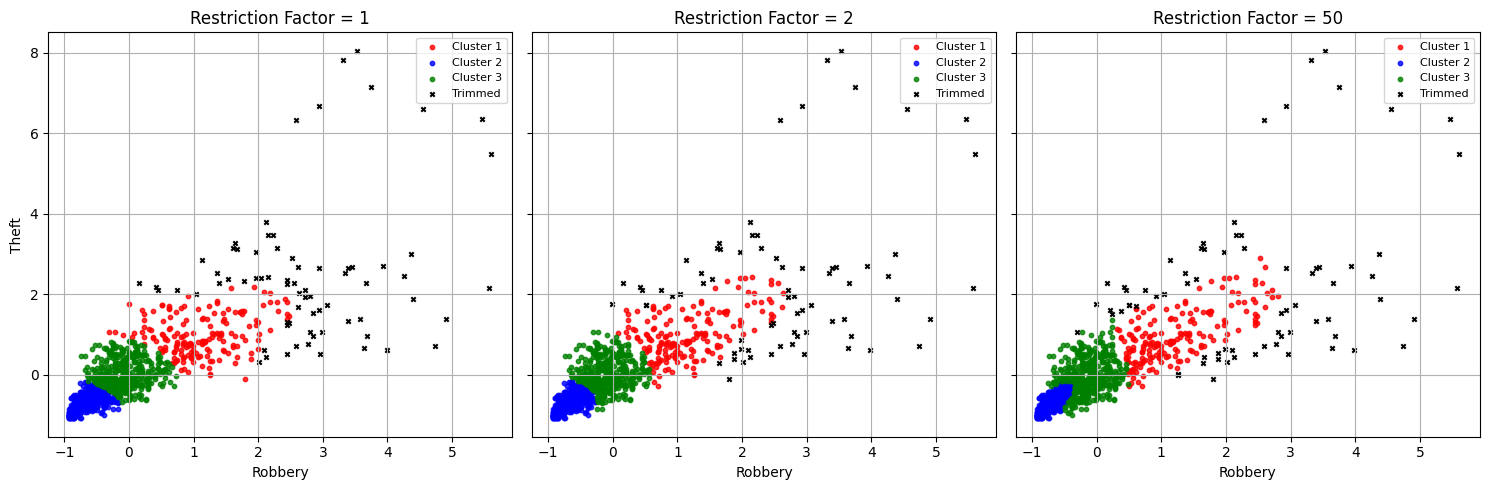

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from numpy.linalg import eigh, inv, cholesky
from scipy.stats import chi2

# CSV dosyasını yükle
df = pd.read_csv("Berlin_crimes.csv")  # ← Dosya burada olmalı
features = ['Robbery', 'Theft']
X_raw = df[features].dropna().values
scaler = StandardScaler().fit(X_raw)
X = scaler.transform(X_raw)

# Restriction: Kovaryans matrislerine sınır getir
def apply_restriction(covs, c):
    adjusted_covs = []
    for cov in covs:
        eigvals, eigvecs = eigh(cov)
        eigvals = np.clip(eigvals, eigvals.max() / c, eigvals.max())  # sınırla
        adjusted_cov = eigvecs @ np.diag(eigvals) @ eigvecs.T
        adjusted_covs.append(adjusted_cov)
    return np.array(adjusted_covs)

# Elips çizimi
def plot_ellipse(ax, mean, cov, color='black', confidence=0.75):
    scale = np.sqrt(chi2.ppf(confidence, df=2))
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    width, height = 2 * scale * np.sqrt(eigvals)
    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle,
                      edgecolor=color, facecolor='none', linewidth=2)
    ax.add_patch(ellipse)

# TCLUST görselleştirme
def tclust_plot(X, scaler, k=3, alpha=0.05, c_values=[1, 2, 5, 50], random_state=42):
    n = X.shape[0]
    total_trim = int(alpha * n)
    colors = ['red', 'blue', 'green', 'purple', 'orange', 'cyan']

    fig, axes = plt.subplots(1, len(c_values), figsize=(5 * len(c_values), 5), sharex=True, sharey=True)

    for idx, c in enumerate(c_values):
        ax = axes[idx] if len(c_values) > 1 else axes
        np.random.seed(random_state)
        trimmed_mask = np.zeros(n, dtype=bool)

        for _ in range(10):  # max iter
            X_clean = X[~trimmed_mask]
            if len(X_clean) <= k + 1:
                break

            gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=random_state)
            gmm.fit(X_clean)

            if c < np.inf:
                gmm.covariances_ = apply_restriction(gmm.covariances_, c)
                gmm.precisions_cholesky_ = cholesky(inv(gmm.covariances_))

            log_likelihoods = gmm.score_samples(X_clean)
            trim_left = total_trim - np.sum(trimmed_mask)
            if trim_left <= 0:
                break

            remaining_idx = np.where(~trimmed_mask)[0]
            trim_now_local = np.argsort(log_likelihoods)[:trim_left]
            trim_now_global = remaining_idx[trim_now_local]
            trimmed_mask[trim_now_global] = True

        # Final fit
        X_final = X[~trimmed_mask]
        gmm_final = GaussianMixture(n_components=k, covariance_type='full', random_state=random_state)
        gmm_final.fit(X_final)

        if c < np.inf:
            gmm_final.covariances_ = apply_restriction(gmm_final.covariances_, c)
            gmm_final.precisions_cholesky_ = cholesky(inv(gmm_final.covariances_))

        labels = gmm_final.predict(X_final)

        for i in range(k):
            cluster_points = X_final[labels == i]
            ax.scatter(cluster_points[:, 0], cluster_points[:, 1], s=10,
                       label=f'Cluster {i+1}', alpha=0.8, color=colors[i % len(colors)])
            #plot_ellipse(ax, gmm_final.means_[i], gmm_final.covariances_[i], color="black")

        ax.scatter(X[trimmed_mask][:, 0], X[trimmed_mask][:, 1],
                   s=10, c='black', marker='x', label='Trimmed')
        ax.set_title(f"Restriction Factor = {c}")
        ax.set_xlabel("Robbery")
        if idx == 0:
            ax.set_ylabel("Theft")
        ax.grid(True)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig("tclust_restriction_fixed_output.png", dpi=300)
    plt.show()

# Run
tclust_plot(X, scaler, k=3, alpha=0.06, c_values=[1, 2, 50])





# trimmed medoid with solutte

In [12]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import random
import seaborn as sns

# Load data
"""data = pd.read_csv("Berlin_crimes.csv")
X = data[['Robbery', 'Theft']].dropna().values
X = StandardScaler().fit_transform(X)"""

df = pd.read_csv("Berlin_crimes.csv")

features = ['Robbery', 'Theft']


# Step 1: Group raw (unscaled) data by region
grouped = df.groupby(['District', 'Location'])[features].mean().reset_index()


# Step 2: Standardize only Robbery and Theft columns
scaler = StandardScaler()
grouped_scaled = grouped.copy()
grouped_scaled[features] = scaler.fit_transform(grouped[features])
grouped=grouped_scaled

# Step 3: Extract X for clustering
X = grouped_scaled[features].values

# Reuse user's functions
def trimmed_kmedoids(X, n_clusters=3, trim_fraction=0.10, max_iter=100,n_init=20, random_state=42):
    
    n_samples = len(X)
    n_trim = int(trim_fraction * n_samples)

    best_labels = None
    best_medoids = None
    best_trim_idx = None
    best_cost = np.inf

    # Initialize medoids randomly from data
    for tt in range(n_init):
        medoid_indices = np.random.choice(n_samples, size=n_clusters, replace=False)
        medoids = X[medoid_indices]

        for _ in range(max_iter):
        # Compute distances from each point to all medoids
            dists = cdist(X, medoids, metric='euclidean')
            min_dists = np.min(dists, axis=1)

        # Trim the farthest points
            trim_idx = np.argsort(min_dists)[-n_trim:]
            keep_mask = np.ones(n_samples, dtype=bool)
            keep_mask[trim_idx] = False

        # Assign labels for only the untrimmed points
            untrimmed_dists = dists[keep_mask]
            labels = np.argmin(untrimmed_dists, axis=1)

            new_medoids = []
            for i in range(n_clusters):
                cluster_points = X[keep_mask][labels == i]
                if len(cluster_points) == 0:
                # If a cluster is empty, reassign a random medoid
                    new_medoids.append(X[np.random.choice(n_samples)])
                    continue
            # Compute total cost of each point being the medoid
                intra_dists = cdist(cluster_points, cluster_points)
                total_cost = np.sum(intra_dists, axis=1)
                best_medoid = cluster_points[np.argmin(total_cost)]
                new_medoids.append(best_medoid)
            new_medoids = np.array(new_medoids)

            if np.allclose(medoids, new_medoids):
                break
            medoids = new_medoids

        final_dists = cdist(X, medoids, metric='euclidean')
        mask = np.ones(n_samples, dtype=bool)
        mask[trim_idx] = False
        run_cost = np.sum(np.min(final_dists[mask], axis=1))

        if run_cost < best_cost:
            best_cost = run_cost
            best_medoids = medoids
            best_trim_idx = trim_idx
            best_labels = np.argmin(final_dists, axis=1)
            best_labels[trim_idx] = -1


    untrimmed_mask = best_labels != -1
    labels_clean = best_labels[untrimmed_mask]
    X_clean = X[untrimmed_mask]

            

    return labels_clean, best_trim_idx

# Grid search
alphas = np.linspace(0.0, 0.10, 11)
ks = list(range(2, 6))
results_kmedoids = np.zeros((len(ks), len(alphas)))

for i, k in enumerate(ks):
    for j, alpha in enumerate(alphas):
        try:
            labels, trimmed_idx = trimmed_kmedoids(X, n_clusters=k, trim_fraction=alpha)
            mask = np.ones(len(X), dtype=bool)
            mask[trimmed_idx] = False
            score = silhouette_score(X[mask], labels) if len(set(labels)) > 1 else -1
            results_kmedoids[i, j] = score
        except Exception:
            results_kmedoids[i, j] = -1

# Convert to DataFrame for display
results_df = pd.DataFrame(results_kmedoids, index=[f'k={k}' for k in ks],
                          columns=[f'α={round(a,2)}' for a in alphas])

results_df

,α=0.0,α=0.01,α=0.02,α=0.03,α=0.04,α=0.05,α=0.06,α=0.07,α=0.08,α=0.09,α=0.1
k=2,-1.0,0.609522,0.548867,0.552486,0.560799,0.548817,0.557268,0.560283,0.564822,0.566400,0.569433
k=3,-1.0,0.521340,0.530284,0.533627,0.532367,0.534119,0.536578,0.539547,0.546759,0.548977,0.554834
k=4,-1.0,0.423998,0.434854,0.438491,0.434678,0.435000,0.447747,0.454297,0.463613,0.468035,0.468954
k=5,-1.0,0.449644,0.386112,0.385672,0.385322,0.386042,0.396436,0.395239,0.400338,0.402221,0.422289


In [13]:
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances_argmin_min

def trimmed_kmeans(X, n_clusters=3, alpha=0.1, n_init=20, max_iter=100, random_state=None):
    """
    Trimmed K-Means clustering.
    - X: data array (n_samples, n_features)
    - n_clusters: number of clusters
    - alpha: trimming fraction (0 <= alpha < 1)
    - n_init: number of random initializations
    - max_iter: max iterations per initialization
    - random_state: random seed
    Returns:
      labels_clean: labels for untrimmed points
      best_trimmed_idx: indices of trimmed points
    """
    if random_state is not None:
        np.random.seed(random_state)

    best_inertia = np.inf
    best_centroids = None
    best_labels = None
    best_trimmed_idx = None

    n_trim = int(alpha * len(X))

    for _ in range(n_init):
        # Initialize centroids randomly
        centroids = X[np.random.choice(len(X), n_clusters, replace=False)]
        for _ in range(max_iter):
            labels, distances = pairwise_distances_argmin_min(X, centroids)

            if n_trim > 0:
                sorted_idx = np.argsort(distances)
                keep_idx = sorted_idx[:-n_trim]
            else:
                keep_idx = np.arange(len(X))  # keep all points

            # Update centroids
            new_centroids = []
            for k in range(n_clusters):
                members = X[keep_idx][labels[keep_idx] == k]
                if len(members) > 0:
                    new_centroids.append(members.mean(axis=0))
                else:
                    new_centroids.append(X[np.random.choice(len(X))])
            centroids = np.vstack(new_centroids)

        # Final distance computation
        labels, distances = pairwise_distances_argmin_min(X, centroids)
        if n_trim > 0:
            sorted_idx = np.argsort(distances)
            trimmed_idx = sorted_idx[-n_trim:]
        else:
            trimmed_idx = np.array([], dtype=int)

        trimmed_inertia = np.sum(np.sort(distances)[:-n_trim]**2) if n_trim > 0 else np.sum(distances**2)

        if trimmed_inertia < best_inertia:
            best_inertia = trimmed_inertia
            best_centroids = centroids
            best_labels = labels
            best_trimmed_idx = trimmed_idx

    # Assign -1 to trimmed points
    final_labels = best_labels.copy()
    if len(best_trimmed_idx) > 0:
        final_labels[best_trimmed_idx] = -1

    # Return only untrimmed labels
    untrimmed_mask = final_labels != -1
    labels_clean = final_labels[untrimmed_mask]

    return labels_clean, best_trimmed_idx


# Example usage with silhouette loop
alphas = np.linspace(0.0, 0.15, 6)
ks = list(range(2, 6))
results_kmeans = np.zeros((len(ks), len(alphas)))

for i, k in enumerate(ks):
    for j, alphat in enumerate(alphas):
        try:
            labels, trimmed_idx = trimmed_kmeans(X, n_clusters=k, alpha=alphat)
            mask = np.ones(len(X), dtype=bool)
            mask[trimmed_idx] = False
            if len(set(labels)) > 1:
                score = silhouette_score(X[mask], labels)
            else:
                score = -1
            results_kmeans[i, j] = score
        except Exception:
            results_kmeans[i, j] = -1

results_df = pd.DataFrame(
    results_kmeans,
    index=[f'k={k}' for k in ks],
    columns=[f'α={round(a,2)}' for a in alphas]
)

print(results_df)

        α=0.0    α=0.03    α=0.06    α=0.09    α=0.12    α=0.15
k=2  0.689896  0.665234  0.606958  0.579778  0.579029  0.571353
k=3  0.582199  0.537857  0.543499  0.549951  0.556040  0.471777
k=4  0.522764  0.546125  0.459856  0.449451  0.471104  0.479037
k=5  0.525689  0.440510  0.409118  0.416225  0.432658  0.442131


# General Comparison with Silhouette

In [14]:

def trimmed_kmedoids(X, n_clusters=3, trim_fraction=0.10, max_iter=55,n_init=20, random_state=42):
    
    n_samples = len(X)
    n_trim = int(trim_fraction * n_samples)

    best_labels = None
    best_medoids = None
    best_trim_idx = None
    best_cost = np.inf

    # Initialize medoids randomly from data
    for tt in range(n_init):
        medoid_indices = np.random.choice(n_samples, size=n_clusters, replace=False)
        medoids = X[medoid_indices]

        for _ in range(max_iter):
        # Compute distances from each point to all medoids
            dists = cdist(X, medoids, metric='euclidean')
            min_dists = np.min(dists, axis=1)

        # Trim the farthest points
            trim_idx = np.argsort(min_dists)[-n_trim:]
            keep_mask = np.ones(n_samples, dtype=bool)
            keep_mask[trim_idx] = False

        # Assign labels for only the untrimmed points
            untrimmed_dists = dists[keep_mask]
            labels = np.argmin(untrimmed_dists, axis=1)

            new_medoids = []
            for i in range(n_clusters):
                cluster_points = X[keep_mask][labels == i]
                if len(cluster_points) == 0:
                # If a cluster is empty, reassign a random medoid
                    new_medoids.append(X[np.random.choice(n_samples)])
                    continue
            # Compute total cost of each point being the medoid
                intra_dists = cdist(cluster_points, cluster_points)
                total_cost = np.sum(intra_dists, axis=1)
                best_medoid = cluster_points[np.argmin(total_cost)]
                new_medoids.append(best_medoid)
            new_medoids = np.array(new_medoids)

            if np.allclose(medoids, new_medoids):
                break
            medoids = new_medoids

        final_dists = cdist(X, medoids, metric='euclidean')
        mask = np.ones(n_samples, dtype=bool)
        mask[trim_idx] = False
        run_cost = np.sum(np.min(final_dists[mask], axis=1))

        if run_cost < best_cost:
            best_cost = run_cost
            best_medoids = medoids
            best_trim_idx = trim_idx
            best_labels = np.argmin(final_dists, axis=1)
            best_labels[trim_idx] = -1


    untrimmed_mask = best_labels != -1
    labels_clean = best_labels[untrimmed_mask]
    X_clean = X[untrimmed_mask]

            

    return labels_clean, best_trim_idx


def trimmed_kmeans(X, n_clusters=3, trim_fraction=0.1, n_init=20, max_iter=55):
    best_inertia = np.inf
    best_centroids = None
    best_labels = None
    best_trimmed_idx = None

    n_trim = int(trim_fraction * len(X))

    for _ in range(n_init):
        centroids = X[np.random.choice(len(X), n_clusters, replace=False)]
        for _ in range(max_iter):
            labels, distances = pairwise_distances_argmin_min(X, centroids)
            sorted_idx = np.argsort(distances)
            keep_idx = sorted_idx[:-n_trim]

            new_centroids = []
            for k in range(n_clusters):
                members = X[keep_idx][labels[keep_idx] == k]
                if len(members) > 0:
                    new_centroids.append(members.mean(axis=0))
                else:
                    new_centroids.append(X[np.random.choice(len(X))])
            centroids = np.vstack(new_centroids)

        labels, distances = pairwise_distances_argmin_min(X, centroids)
        trimmed_inertia = np.sum(np.sort(distances)[:-n_trim]**2)
        if trimmed_inertia < best_inertia:
            best_inertia = trimmed_inertia
            best_centroids = centroids
            best_labels = labels
            best_trimmed_idx = sorted_idx[-n_trim:]

    # Assign -1 to trimmed outliers
    best_labels[best_trimmed_idx] = -1

    untrimmed_mask = best_labels != -1
    labels_clean = best_labels[untrimmed_mask]
    X_clean = X[untrimmed_mask]

    return labels_clean, best_trimmed_idx



def t_clust_gmm(X, n_clusters=4, trim_fraction=0.1, restriction=1.5, max_iter=10, random_state=42):
    """
    T-Clust implementation:
    - Iteratively trims the α-fraction of points with the lowest log-likelihood.
    - Applies eigenvalue restriction after final GMM fit.

    Returns:
        - labels_clean: Cluster labels for untrimmed points
        - trimmed_idx: Indices of trimmed (outlier) points
    """
    np.random.seed(random_state)
    n_samples = X.shape[0]
    total_trim = int(trim_fraction * n_samples)
    trimmed_mask = np.zeros(n_samples, dtype=bool)

    for _ in range(max_iter):
        X_remaining = X[~trimmed_mask]
        if len(X_remaining) <= n_clusters + 1:
            break

        gmm = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=random_state)
        gmm.fit(X_remaining)
        log_likelihood = gmm.score_samples(X_remaining)

        trim_left = total_trim - np.sum(trimmed_mask)
        if trim_left <= 0:
            break

        remaining_idx = np.where(~trimmed_mask)[0]
        trim_now_local_idx = np.argsort(log_likelihood)[:trim_left]
        trim_now_global_idx = remaining_idx[trim_now_local_idx]
        trimmed_mask[trim_now_global_idx] = True

    # Final GMM fit on untrimmed data
    X_clean = X[~trimmed_mask]
    gmm_final = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=random_state)
    gmm_final.fit(X_clean)

    # Apply eigenvalue restriction to final covariances
    def apply_restriction(covariances, c):
        adjusted_covs = []
        for cov in covariances:
            eigvals, eigvecs = np.linalg.eigh(cov)
            max_eig = eigvals.max()
            min_allowed = max_eig / c
            eigvals = np.clip(eigvals, min_allowed, max_eig)
            adjusted_cov = eigvecs @ np.diag(eigvals) @ eigvecs.T
            adjusted_covs.append(adjusted_cov)
        return np.array(adjusted_covs)

    adjusted_covs = apply_restriction(gmm_final.covariances_, restriction)
    gmm_final.covariances_ = adjusted_covs
    gmm_final.precisions_cholesky_ = np.linalg.cholesky(np.linalg.inv(adjusted_covs))

    labels_clean = gmm_final.predict(X_clean)
    trimmed_idx = np.where(trimmed_mask)[0]

    return labels_clean, trimmed_idx







# === Grid search ===

def silhouette_grid_search(X, method, ks, alphas, c):
    results = {}
    for k in ks:
        for alpha in alphas:
            for c1 in c:
                try:
                    if method == 'kmeans':
                        labels, trimmed = trimmed_kmeans(X, n_clusters=k, trim_fraction=alpha)
                    elif method == 'kmedoids':
                        labels, trimmed = trimmed_kmedoids(X, n_clusters=k, trim_fraction=alpha)
                    else:
                        continue
                    X_untrimmed = np.delete(X, trimmed, axis=0)
                    if len(np.unique(labels)) > 1:
                        sil = silhouette_score(X_untrimmed, labels)
                        results[(k, alpha)] = sil
                except:
                    continue
    return results

def silhouette_grid_search_t_clust(X, method, ks, alphas, c):
    results = {}
    for k in ks:
        for alpha in alphas:
            for c1 in c:
                try:
                    if method == 'tclust':
                        labels, trimmed = t_clust_gmm(X, n_clusters=k, trim_fraction=alpha, restriction = c1)
                    else:
                        continue
                    X_untrimmed = np.delete(X, trimmed, axis=0)
                    if len(np.unique(labels)) > 1:
                        sil = silhouette_score(X_untrimmed, labels)
                        results[(k, alpha, c1)] = sil
                except:
                    continue
    return results

df = pd.read_csv("Berlin_crimes.csv")

features = ['Robbery', 'Theft']


# Step 1: Group raw (unscaled) data by region
grouped = df.groupby(['District', 'Location'])[features].mean().reset_index()


# Step 2: Standardize only Robbery and Theft columns
scaler = StandardScaler()
grouped_scaled = grouped.copy()
grouped_scaled[features] = scaler.fit_transform(grouped[features])
grouped=grouped_scaled

# Step 3: Extract X for clustering
X = grouped_scaled[features].values

ks = list(range(2, 5))
alphas = np.linspace(0, 0.1, 11)
restriction_factors = [1, 1.5, 2, 5, 10, 50]
restriction_factorsk = [1]

methods = ['kmeans', 'kmedoids', 'tclust']
final_results = {}
final_results_2 = {}

for method in methods:
    print(f"Running: {method}")
    res = silhouette_grid_search(X, method, ks, alphas, restriction_factorsk)
    final_results[method] = res
    res = silhouette_grid_search_t_clust(X, method, ks, alphas, restriction_factors)
    final_results_2[method] = res
    print(f"Done with {method}")

# Save to CSV
for method in final_results:
    if method == 'tclust':
      rows = [{"k": k, "alpha": alpha, "c": c, "silhouette": sil} for (k, alpha, c), sil in final_results_2[method].items()]
      pd.DataFrame(rows).to_csv(f"{method}_silhouette_results.csv", index=False)
    else:
      rows = [{"k": k, "alpha": alpha, "silhouette": sil} for (k, alpha), sil in final_results[method].items()]
      pd.DataFrame(rows).to_csv(f"{method}_silhouette_results.csv", index=False)

Running: kmeans
Done with kmeans
Running: kmedoids
Done with kmedoids
Running: tclust
Done with tclust


In [15]:
from collections import defaultdict

# Load data
df = pd.read_csv("Berlin_crimes.csv")

features = ['Robbery', 'Theft']


# Step 1: Group raw (unscaled) data by region
grouped = df.groupby(['District', 'Location'])[features].mean().reset_index()


# Step 2: Standardize only Robbery and Theft columns
scaler = StandardScaler()
grouped_scaled = grouped.copy()
grouped_scaled[features] = scaler.fit_transform(grouped[features])
grouped=grouped_scaled

# Step 3: Extract X for clustering
X = grouped_scaled[features].values

X_rlg = X


X_rclr = X[:, [0]]
y_rclr = X[:, 1]

# Parameters
alphas = np.linspace(0, 0.10, 11)
ks = list(range(1, 5))
restriction_factors = [1,1.5, 2, 3, 5, 10, 50]


results_rlg = np.zeros((len(ks), len(alphas)))
results_rclr = np.zeros((len(ks), len(alphas)))

for i, k in enumerate(ks):
    for j, alpha in enumerate(alphas):
        try:
            labels, trimmed_idx = robust_linear_grouping(X_rlg, n_clusters=k, trim_fraction=alpha)
            mask = np.ones(len(X), dtype=bool)
            mask[trimmed_idx] = False
            score = silhouette_score(X[mask], labels) if len(set(labels)) > 1 else -1
            results_rlg[i, j] = score
        except Exception:
            results_rlg[i, j] = -1

        try:
            labels, trimmed_idx = robust_clusterwise_linear_regression(X_rclr, y_rclr, n_clusters=k, trim_fraction=alpha)
            mask = np.ones(len(X), dtype=bool)
            mask[trimmed_idx] = False
            score = silhouette_score(X[mask], labels) if len(set(labels)) > 1 else -1
            results_rclr[i, j] = score
        except Exception:
            results_rclr[i, j] = -1

# Convert to DataFrames
results_rlg_df = pd.DataFrame(results_rlg, index=[f'k={k}' for k in ks], columns=[f'α={round(a, 2)}' for a in alphas])
results_rclr_df = pd.DataFrame(results_rclr, index=[f'k={k}' for k in ks], columns=[f'α={round(a, 2)}' for a in alphas])

# Grid search for trimmed K-Medoids
results_kmedoids = np.zeros((len(ks), len(alphas)))
for i, k in enumerate(ks):
    for j, alpha in enumerate(alphas):
        try:
            labels, trimmed_idx = trimmed_kmedoids(X, n_clusters=k, trim_fraction=alpha)
            mask = np.ones(len(X), dtype=bool)
            mask[trimmed_idx] = False
            score = silhouette_score(X[mask], labels) if len(set(labels)) > 1 else -1
            results_kmedoids[i, j] = score
        except Exception:
            results_kmedoids[i, j] = -1
results_kmedoids_df = pd.DataFrame(results_kmedoids, index=[f'k={k}' for k in ks], columns=[f'α={round(a, 2)}' for a in alphas])

# Grid search for trimmed K-Means
results_kmeans = np.zeros((len(ks), len(alphas)))
for i, k in enumerate(ks):
    for j, alpha in enumerate(alphas):
        try:
            labels, trimmed_idx = trimmed_kmeans(X, n_clusters=k, trim_fraction=alpha)
            mask = np.ones(len(X), dtype=bool)
            mask[trimmed_idx] = False
            score = silhouette_score(X[mask], labels) if len(set(labels)) > 1 else -1
            results_kmeans[i, j] = score
        except Exception:
            results_kmeans[i, j] = -1
results_kmeans_df = pd.DataFrame(results_kmeans, index=[f'k={k}' for k in ks], columns=[f'α={round(a, 2)}' for a in alphas])

# Grid search for T-Clust

results_tclust = defaultdict(lambda: np.zeros((len(ks), len(alphas))))
for c in restriction_factors:
    for i, k in enumerate(ks):
        for j, alpha in enumerate(alphas):
            try:
                labels, trimmed_idx = t_clust_gmm(X, n_clusters=k, trim_fraction=alpha, restriction=c)
                mask = np.ones(len(X), dtype=bool)
                mask[trimmed_idx] = False
                score = silhouette_score(X[mask], labels) if len(set(labels)) > 1 else -1
                results_tclust[c][i, j] = score
            except Exception:
                results_tclust[c][i, j] = -1
results_tclust_df = {c: pd.DataFrame(results_tclust[c], index=[f'k={k}' for k in ks], columns=[f'α={round(a, 2)}' for a in alphas]) for c in restriction_factors}

results_kmeans_df.head(), results_tclust_df[2].head()


(     α=0.0    α=0.01    α=0.02    α=0.03    α=0.04    α=0.05    α=0.06  \
 k=1   -1.0 -1.000000 -1.000000 -1.000000 -1.000000 -1.000000 -1.000000   
 k=2   -1.0  0.681033  0.667708  0.665234  0.613041  0.612284  0.606958   
 k=3   -1.0  0.540940  0.536151  0.539478  0.539580  0.541069  0.543499   
 k=4   -1.0  0.529217  0.537674  0.538349  0.451148  0.453648  0.459856   
 
        α=0.07    α=0.08    α=0.09     α=0.1  
 k=1 -1.000000 -1.000000 -1.000000 -1.000000  
 k=2  0.605103  0.579810  0.579778  0.580436  
 k=3  0.546948  0.549477  0.549951  0.554890  
 k=4  0.443598  0.464994  0.470065  0.454669  ,
         α=0.0    α=0.01    α=0.02    α=0.03    α=0.04    α=0.05    α=0.06  \
 k=1 -1.000000 -1.000000 -1.000000 -1.000000 -1.000000 -1.000000 -1.000000   
 k=2  0.684935  0.594833  0.593063  0.593763  0.580530  0.582140  0.595672   
 k=3  0.561370  0.525930  0.530130  0.539359  0.545691  0.547433  0.548856   
 k=4  0.524085  0.537173  0.543287  0.403557  0.397322  0.399809  0.405517 

In [16]:
best_score_kmedoids = np.max(results_kmedoids)
best_params_kmedoids = np.unravel_index(np.argmax(results_kmedoids), results_kmedoids.shape)
best_k_kmedoids = ks[best_params_kmedoids[0]]
best_alpha_kmedoids = alphas[best_params_kmedoids[1]]

best_score_kmeans = np.max(results_kmeans)
best_params_kmeans = np.unravel_index(np.argmax(results_kmeans), results_kmeans.shape)
best_k_kmeans = ks[best_params_kmeans[0]]
best_alpha_kmeans = alphas[best_params_kmeans[1]]

best_score_rlg = np.max(results_rlg)
best_params_rlg = np.unravel_index(np.argmax(results_rlg), results_rlg.shape)
best_k_rlg = ks[best_params_rlg[0]]
best_alpha_rlg = alphas[best_params_rlg[1]]

best_score_rclr = np.max(results_rclr)
best_params_rclr = np.unravel_index(np.argmax(results_rclr), results_rclr.shape)
best_k_rclr = ks[best_params_rclr[0]]
best_alpha_rclr = alphas[best_params_rclr[1]]

best_score_tclust = -1
best_params_tclust = None
best_c_tclust = None
for c, df in results_tclust_df.items():
    score = df.to_numpy().max()
    if score > best_score_tclust:
        best_score_tclust = score
        idx = np.unravel_index(np.argmax(df.to_numpy()), df.shape)
        best_params_tclust = (ks[idx[0]], alphas[idx[1]])
        best_c_tclust = c


all_scores = {
    'Trimmed K-Medoids': best_score_kmedoids,
    'Trimmed K-Means': best_score_kmeans,
    f'T-Clust (c={best_c_tclust})': best_score_tclust,
    'Robust Linear Grouping': best_score_rlg,
    'Robust Clusterwise Linear Regression': best_score_rclr
}

best_method = max(all_scores, key=all_scores.get)
best_overall_score = all_scores[best_method]

# Determine best config
if best_method == 'Trimmed K-Medoids':
    best_config = (best_k_kmedoids, best_alpha_kmedoids)
elif best_method == 'Trimmed K-Means':
    best_config = (best_k_kmeans, best_alpha_kmeans)
elif best_method.startswith('T-Clust'):
    best_config = best_params_tclust
elif best_method == 'Robust Linear Grouping':
    best_config = (best_k_rlg, best_alpha_rlg)
else:
    best_config = (best_k_rclr, best_alpha_rclr)

# Build summary dataframe
summary_data = {
    "Method": [
        "Trimmed K-Medoids",
        "Trimmed K-Means",
        f"T-Clust (c={best_c_tclust})",
        "Robust Linear Grouping",
        "Robust Clusterwise Linear Regression",
        "Best Overall"
    ],
    "Best k": [
        best_k_kmedoids,
        best_k_kmeans,
        best_params_tclust[0],
        best_k_rlg,
        best_k_rclr,
        best_config[0]
    ],
    "Best α": [
        round(best_alpha_kmedoids, 2),
        round(best_alpha_kmeans, 2),
        round(best_params_tclust[1], 2),
        round(best_alpha_rlg, 2),
        round(best_alpha_rclr, 2),
        round(best_config[1], 2)
    ],
    "Silhouette Score": [
        best_score_kmedoids,
        best_score_kmeans,
        best_score_tclust,
        best_score_rlg,
        best_score_rclr,
        best_overall_score
    ],
}

summary_df = pd.DataFrame(summary_data)

In [17]:
summary_df

,Method,Best k,Best α,Silhouette Score
0,Trimmed K-Medoids,2,0.01,0.637958
1,Trimmed K-Means,2,0.01,0.681033
2,T-Clust (c=3),2,0.00,0.689896
3,Robust Linear Grouping,2,0.05,0.704163
4,Robust Clusterwise Linear Regression,2,0.02,0.687429
5,Best Overall,2,0.05,0.704163


# Visualization

Visualize and interpret the clusterings: spatially and by crime types.

# best silhoutte viusal

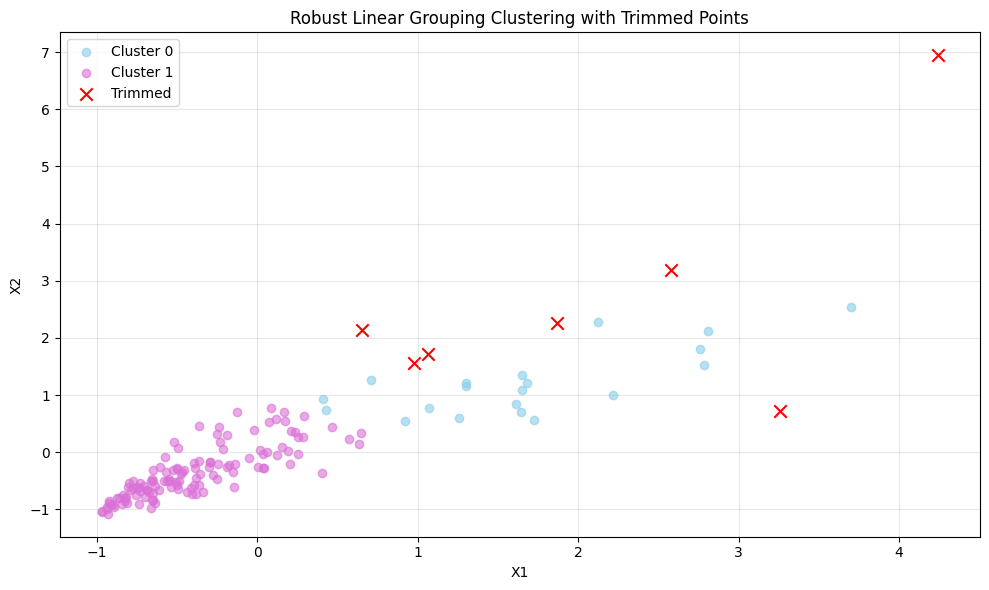

In [27]:
def robust_linear_grouping(X, n_clusters=3, trim_fraction=0.1):
    from sklearn.linear_model import RANSACRegressor
    from sklearn.cluster import KMeans

    # Step 1: Fit rough clusters
    kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(X)
    cluster_labels = kmeans.labels_

    # Step 2: Fit linear models per cluster and compute residuals
    residuals = np.zeros(len(X))
    for c in range(n_clusters):
        idx = (cluster_labels == c)
        if idx.sum() < 2:
            residuals[idx] = float('inf')
            continue

        X_c = X[idx]
        model = RANSACRegressor().fit(X_c[:, [0]], X_c[:, 1])
        pred = model.predict(X_c[:, [0]])
        residuals[idx] = np.abs(pred - X_c[:, 1])

    # Step 3: Trim top residuals
    n_trim = int(trim_fraction * len(X))
    trim_indices = np.argsort(residuals)[-n_trim:]

    # Step 4: Re-cluster untrimmed
    mask = np.ones(len(X), dtype=bool)
    mask[trim_indices] = False
    X_untrimmed = X[mask]
    final_labels = KMeans(n_clusters=n_clusters, random_state=42).fit_predict(X_untrimmed)

    return final_labels, trim_indices



final_labels, trim_indices = robust_linear_grouping(X, n_clusters=2, trim_fraction=0.05)


# Assuming you have already loaded your data and run:
# final_labels, trim_indices = robust_linear_grouping(X, n_clusters=3, trim_fraction=0.1)

# Convert data to DataFrame for easy plotting
df = pd.DataFrame(X, columns=["X1", "X2"])
df['Cluster'] = -1
df['Trimmed'] = False

# Assign labels and trimming info
mask = np.ones(len(X), dtype=bool)
mask[trim_indices] = False
df.loc[mask, 'Cluster'] = final_labels
df.loc[trim_indices, 'Trimmed'] = True

# Plot
plt.figure(figsize=(10, 6))
colors = ['skyblue', 'orchid', 'lightgreen', 'gold', 'salmon']

for c in sorted(df['Cluster'].unique()):
    if c == -1:
        continue
    cluster_df = df[(df['Cluster'] == c) & (~df['Trimmed'])]
    plt.scatter(cluster_df['X1'], cluster_df['X2'], label=f'Cluster {c}', color=colors[c % len(colors)], alpha=0.6)

# Plot trimmed points
trimmed_df = df[df['Trimmed']]
plt.scatter(trimmed_df['X1'], trimmed_df['X2'], color='red', marker='x', s=80, label='Trimmed')

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Robust Linear Grouping Clustering with Trimmed Points")
plt.legend()
plt.savefig("bestsilhoutteplot.png")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show();





In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Load the data
df = pd.read_csv("Berlin_crimes.csv")

# Extract crime feature columns
crime_types = ['Robbery', 'Street_robbery', 'Injury', 'Agg_assault', 'Threat',
               'Theft', 'Car', 'From_car', 'Bike', 'Burglary', 'Fire', 'Arson',
               'Damage', 'Graffiti', 'Drugs', 'Local']

# Normalize globally
scaler = StandardScaler()
df[crime_types] = scaler.fit_transform(df[crime_types])

# Combine all crimes into one multifeature representation
X_all_crimes = df[crime_types].values

# Trim using GMM with c=1
def t_clust_c1(data, alpha=0.1):
    gmm = GaussianMixture(n_components=1, covariance_type='full', random_state=42).fit(data)
    log_probs = gmm.score_samples(data)
    threshold = np.quantile(log_probs, alpha)
    trimmed = np.where(log_probs < threshold)[0]
    return trimmed

trimmed_indices = t_clust_c1(X_all_crimes, alpha=0.1)
non_trimmed_mask = np.ones(len(df), dtype=bool)
non_trimmed_mask[trimmed_indices] = False

# Cluster the remaining (non-trimmed) data
X_trimmed = X_all_crimes[non_trimmed_mask]
kmeans = KMeans(n_clusters=3, random_state=42).fit(X_trimmed)
df['Cluster'] = -1
df.loc[non_trimmed_mask, 'Cluster'] = kmeans.labels_

# Visualize clusters based on 2D PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all_crimes)
df['PCA1'], df['PCA2'] = X_pca[:, 0], X_pca[:, 1]

plt.figure(figsize=(12, 8))
for c in sorted(df['Cluster'].unique()):
    if c == -1:
        subset = df[df['Cluster'] == c]
        plt.scatter(subset['PCA1'], subset['PCA2'], marker='x', color='red', s=60, label='Trimmed')
    else:
        subset = df[df['Cluster'] == c]
        plt.scatter(subset['PCA1'], subset['PCA2'], s=50, label=f"Cluster {c}")

# Add labels to trimmed
for idx in trimmed_indices:
    plt.text(df.iloc[idx]['PCA1'], df.iloc[idx]['PCA2'],
             f"{df.iloc[idx]['District']} ({df.iloc[idx]['Location']})",
             fontsize=6, alpha=0.6)

plt.title("Combined Crime Profile Clustering (after Trimming)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("./combined_crime_clusters_trimmed.png", dpi=200)
plt.close()


In [20]:
# Redefine the function for T-Clust (c=1) trimming and yearly cluster plotting
crime_features=["Robbery","Theft"]


def t_clust_c1(data, alpha=0.1):
    gmm = GaussianMixture(n_components=1, covariance_type='full', random_state=42).fit(data)
    log_probs = gmm.score_samples(data)
    threshold = np.quantile(log_probs, alpha)
    trimmed = np.where(log_probs < threshold)[0]
    return trimmed

def plot_yearly_clusters(df, crime_features, alpha=0.1):
    years = sorted(df['Year'].unique())
    plot_paths = []

    for year in years:
        df_year = df[df['Year'] == year].copy()
        X = df_year[crime_features].values
        trimmed_idx = t_clust_c1(X, alpha)
        trimmed_mask = np.zeros(len(df_year), dtype=bool)
        trimmed_mask[trimmed_idx] = True

        kmeans = KMeans(n_clusters=3, random_state=42).fit(X[~trimmed_mask])
        df_year.loc[~trimmed_mask, 'Cluster'] = kmeans.labels_
        df_year.loc[trimmed_mask, 'Cluster'] = -1

        plt.figure(figsize=(10, 6))
        for c in range(3):
            subset = df_year[df_year['Cluster'] == c]
            plt.scatter(subset['Theft'], subset['Robbery'], label=f"Cluster {c}", alpha=0.6)
        trimmed_subset = df_year[df_year['Cluster'] == -1]
        plt.scatter(trimmed_subset['Theft'], trimmed_subset['Robbery'], color='red', marker='x', s=80, label='Trimmed')

        for _, row in trimmed_subset.iterrows():
            plt.text(row['Theft'], row['Robbery'], f"{row['District']} ({row['Location']})", fontsize=6, rotation=45)

        plt.title(f"Trimmed Clustering for Year {year}")
        plt.xlabel("Theft (Normalized)")
        plt.ylabel("Robbery (Normalized)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        filename = f"./yearly_trimmed_cluster_{year}.png"
        plt.savefig(filename, dpi=200)
        plt.close()
        plot_paths.append(filename)

    return plot_paths

plot_files = plot_yearly_clusters(df, crime_features)

* 'Injury', 'Agg_assault', 'Threat' (for violent crime)
* 'Car', 'From_car', 'Bike' (for property crime)
* 'Damage', 'Graffiti', 'Arson' (for vandalism)

# Silhouette evaluation for cluster count

* will be added this

# Grouped clustering

In [21]:
# Load dataset
file_path = 'Berlin_crimes.csv'
df = pd.read_csv(file_path)

# Define feature groups
violent_crime_features = ['Injury', 'Agg_assault', 'Threat']
property_crime_features = ['Car', 'From_car', 'Bike']
vandalism_features = ['Damage', 'Graffiti', 'Arson']

# Combine feature groups for multi-feature clustering
selected_features = violent_crime_features + property_crime_features + vandalism_features

# Drop rows with NaNs in selected features
df = df.dropna(subset=selected_features).reset_index(drop=True)

# Normalize globally
scaler = StandardScaler()
df[selected_features] = scaler.fit_transform(df[selected_features])

# T-Clust c=1 function
def t_clust_c1_multi(data, alpha=0.1):
    gmm = GaussianMixture(n_components=1, covariance_type='full', random_state=42).fit(data)
    log_probs = gmm.score_samples(data)
    threshold = np.quantile(log_probs, alpha)
    trimmed = np.where(log_probs < threshold)[0]
    return trimmed

# Apply T-Clust c=1
X = df[selected_features].values
trimmed_indices = t_clust_c1_multi(X, alpha=0.1)

# Add trimmed flag for plotting
df['Trimmed'] = False
df.loc[trimmed_indices, 'Trimmed'] = True


# Save trimmed data for inspection
trimmed_df = df[df['Trimmed']][['District', 'Location'] + selected_features]
trimmed_df_path = "./trimmed_multifeature_points.csv"
trimmed_df.to_csv(trimmed_df_path, index=False)


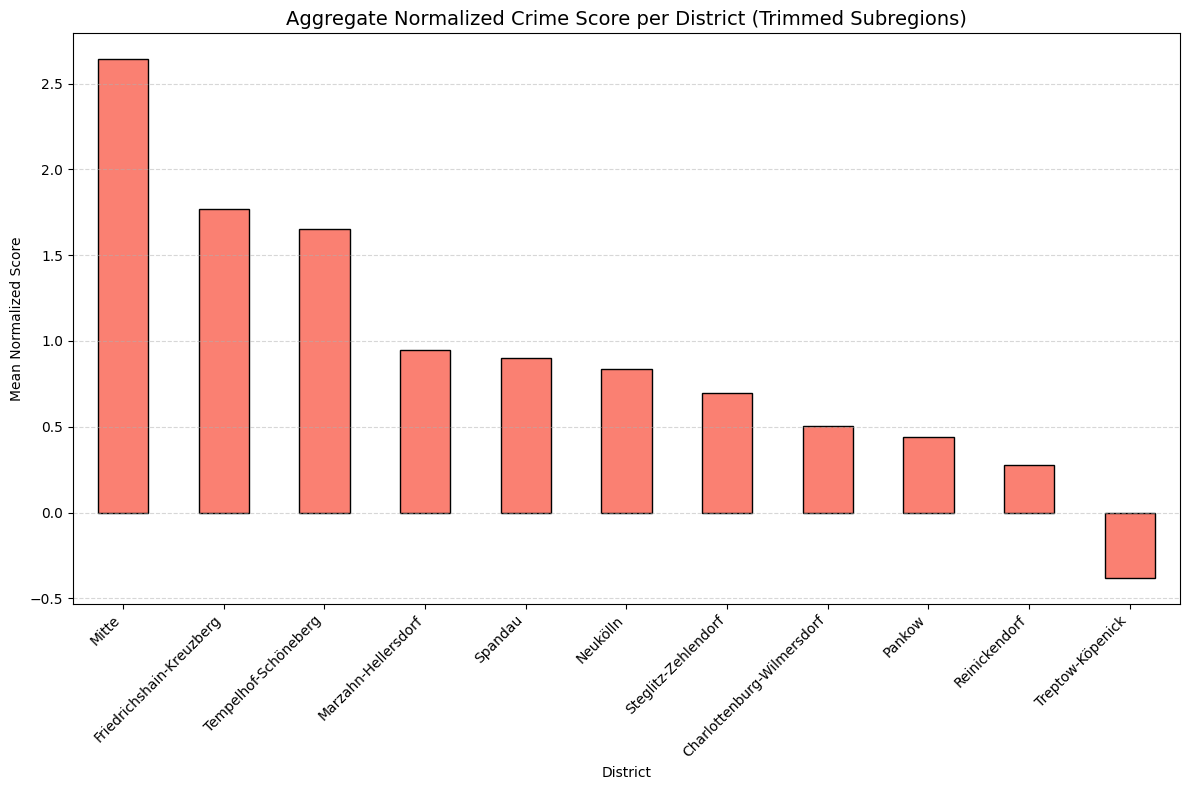

In [22]:
trimmed_df = pd.read_csv("./trimmed_multifeature_points.csv")

# Compute mean normalized score per district
district_scores = trimmed_df.groupby("District")[
    ['Injury', 'Agg_assault', 'Threat', 'Car', 'From_car', 'Bike', 'Damage', 'Graffiti', 'Arson']
].mean().mean(axis=1).sort_values(ascending=False)

# Plotting
plt.figure(figsize=(12, 8))
district_scores.plot(kind='bar', color='salmon', edgecolor='black')
plt.title("Aggregate Normalized Crime Score per District (Trimmed Subregions)", fontsize=14)
plt.ylabel("Mean Normalized Score")
plt.xlabel("District")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [23]:
# Reload full data to recompute avg_full
trimmed_df["ViolentCrime"] = trimmed_df[["Injury", "Agg_assault", "Threat"]].mean(axis=1)
trimmed_df["PropertyCrime"] = trimmed_df[["Car", "From_car", "Bike"]].mean(axis=1)
trimmed_df["Vandalism"] = trimmed_df[["Damage", "Graffiti", "Arson"]].mean(axis=1)
full_df = pd.read_csv("Berlin_crimes.csv")

# Recompute composite scores and normalize
crime_features = ['Injury', 'Agg_assault', 'Threat', 'Car', 'From_car', 'Bike', 'Damage', 'Graffiti', 'Arson']
scaler = StandardScaler()
full_df[crime_features] = scaler.fit_transform(full_df[crime_features])

# Compute composite crime categories
full_df["ViolentCrime"] = full_df[["Injury", "Agg_assault", "Threat"]].mean(axis=1)
full_df["PropertyCrime"] = full_df[["Car", "From_car", "Bike"]].mean(axis=1)
full_df["Vandalism"] = full_df[["Damage", "Graffiti", "Arson"]].mean(axis=1)
full_df['TotalScore'] = full_df[['ViolentCrime', 'PropertyCrime', 'Vandalism']].mean(axis=1)

# Update average crime score
trimmed_df['TotalScore'] = trimmed_df[['ViolentCrime', 'PropertyCrime', 'Vandalism']].mean(axis=1)
avg_trimmed = trimmed_df.groupby("District")["TotalScore"].mean().reset_index()
avg_trimmed['Source'] = "Trimmed"

# Average by district
avg_full = full_df.groupby("District")["TotalScore"].mean().reset_index()
avg_full['Source'] = "All"

combined_avg = pd.concat([avg_full, avg_trimmed])

plt.figure(figsize=(14, 7))
sns.barplot(data=combined_avg, x="District", y="TotalScore", hue="Source", palette="Set2")
plt.xticks(rotation=45, ha="right")
plt.title("Average Normalized Crime Score per District: Trimmed vs All Subregions", fontsize=14)
plt.ylabel("Average Normalized Score")
plt.xlabel("District")
plt.grid(True, axis='y')
plt.tight_layout()
plt.savefig("./compare_trimmed_vs_all_fixed.png", dpi=300)
plt.close()

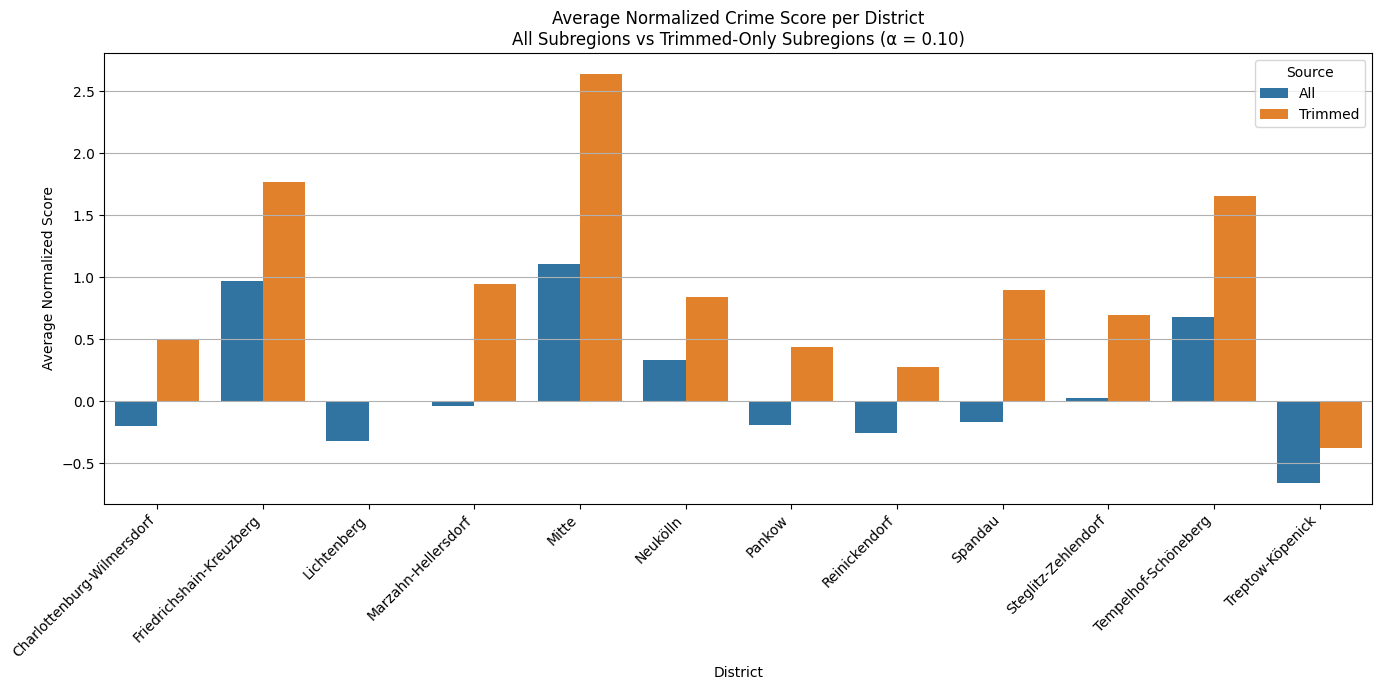

                      District  N_all  N_trimmed
0   Charlottenburg-Wilmersdorf    144        7.0
1     Friedrichshain-Kreuzberg     72       33.0
2                  Lichtenberg    112        NaN
3          Marzahn-Hellersdorf     80       20.0
4                        Mitte     88       17.0
5                     Neukölln     88       13.0
6                       Pankow    136        4.0
7                Reinickendorf     96        2.0
8                      Spandau     80        1.0
9          Steglitz-Zehlendorf     72        6.0
10        Tempelhof-Schöneberg     64       15.0
11            Treptow-Köpenick    168        2.0


In [24]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load & prep ---
file_path = "Berlin_crimes.csv"
base_df = pd.read_csv(file_path)

violent = ['Injury', 'Agg_assault', 'Threat']
property_ = ['Car', 'From_car', 'Bike']
vandal = ['Damage', 'Graffiti', 'Arson']
features = violent + property_ + vandal

# Use the SAME rows for scaling & trimming (drop NaNs once)
base_df = base_df.dropna(subset=features).reset_index(drop=True)

# Global scaling (fit once, apply to the working copy)
scaler = StandardScaler().fit(base_df[features])
df = base_df.copy()
df[features] = scaler.transform(df[features])

# --- Trim with 1-component GMM (proxy for TCLUST with c = ∞, K = 1) ---
def t_clust_c1_multi(data, alpha=0.10, random_state=42):
    gmm = GaussianMixture(n_components=1, covariance_type="full", random_state=random_state).fit(data)
    logp = gmm.score_samples(data)
    thr = np.quantile(logp, alpha)  # lowest alpha fraction trimmed
    return np.where(logp < thr)[0]

X = df[features].values
trimmed_idx = t_clust_c1_multi(X, alpha=0.10)
df["TrimmedFlag"] = False
df.loc[trimmed_idx, "TrimmedFlag"] = True

# --- Composites on the SAME (scaled) frame ---
df["ViolentCrime"]  = df[violent].mean(axis=1)
df["PropertyCrime"] = df[property_].mean(axis=1)
df["Vandalism"]     = df[vandal].mean(axis=1)
df["TotalScore"]    = df[["ViolentCrime", "PropertyCrime", "Vandalism"]].mean(axis=1)

# --- District-level summaries ---
# Means
avg_all = df.groupby("District", as_index=False)["TotalScore"].mean().rename(columns={"TotalScore": "All"})
avg_trimmed = (df.loc[df["TrimmedFlag"]]
                 .groupby("District", as_index=False)["TotalScore"]
                 .mean()
                 .rename(columns={"TotalScore": "Trimmed"}))

# Counts (robust across pandas versions)
cnt_all  = df.groupby("District").size().reset_index(name="N_all")
cnt_trim = df.loc[df["TrimmedFlag"]].groupby("District").size().reset_index(name="N_trimmed")

# Merge and keep all districts
summary = (avg_all
           .merge(avg_trimmed, on="District", how="left")
           .merge(cnt_all, on="District", how="left")
           .merge(cnt_trim, on="District", how="left"))

# Stable order for plotting
district_order = sorted(summary["District"].unique())
summary["District"] = pd.Categorical(summary["District"], categories=district_order, ordered=True)

# Long format for seaborn
plot_df = summary.melt(id_vars=["District","N_all","N_trimmed"],
                       value_vars=["All","Trimmed"],
                       var_name="Source", value_name="TotalScore")

# --- Plot ---
plt.figure(figsize=(14, 7))
sns.barplot(data=plot_df, x="District", y="TotalScore", hue="Source")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Normalized Score")
plt.xlabel("District")
plt.title("Average Normalized Crime Score per District\nAll Subregions vs Trimmed-Only Subregions (α = 0.10)")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# Optional: inspect where trimming happened
print(summary[["District","N_all","N_trimmed"]].sort_values("District"))


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load latest uploaded data
crime_df = pd.read_csv("Berlin_crimes.csv")
trimmed_df = pd.read_csv("./trimmed_multifeature_points.csv")

# Merge PCA and trimming info
crime_features = ['Injury', 'Agg_assault', 'Threat', 'Car', 'From_car', 'Bike', 'Damage', 'Graffiti', 'Arson']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(crime_df[crime_features])

# Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
crime_df['PCA1'] = pca_result[:, 0]
crime_df['PCA2'] = pca_result[:, 1]

# Add trimming information
crime_df['Trimmed'] = crime_df.index.isin(trimmed_df.index)

# Plot
plt.figure(figsize=(12, 8))
for district in crime_df['District'].unique():
    subset = crime_df[(crime_df['District'] == district) & (~crime_df['Trimmed'])]
    plt.scatter(subset['PCA1'], subset['PCA2'], label=district, alpha=0.6, s=60)

# Plot trimmed separately
trimmed = crime_df[crime_df['Trimmed']]
plt.scatter(trimmed['PCA1'], trimmed['PCA2'], color='red', marker='x', s=80, label='Trimmed')

# Annotate trimmed points with subregion
for _, row in trimmed.iterrows():
    plt.text(row['PCA1'], row['PCA2'], f"{row['Location']}", fontsize=7, alpha=0.7)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Crime Features in Berlin (Trimmed vs Untrimmed)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pca_trimmed_untrimmed.png", dpi=300)
plt.close()


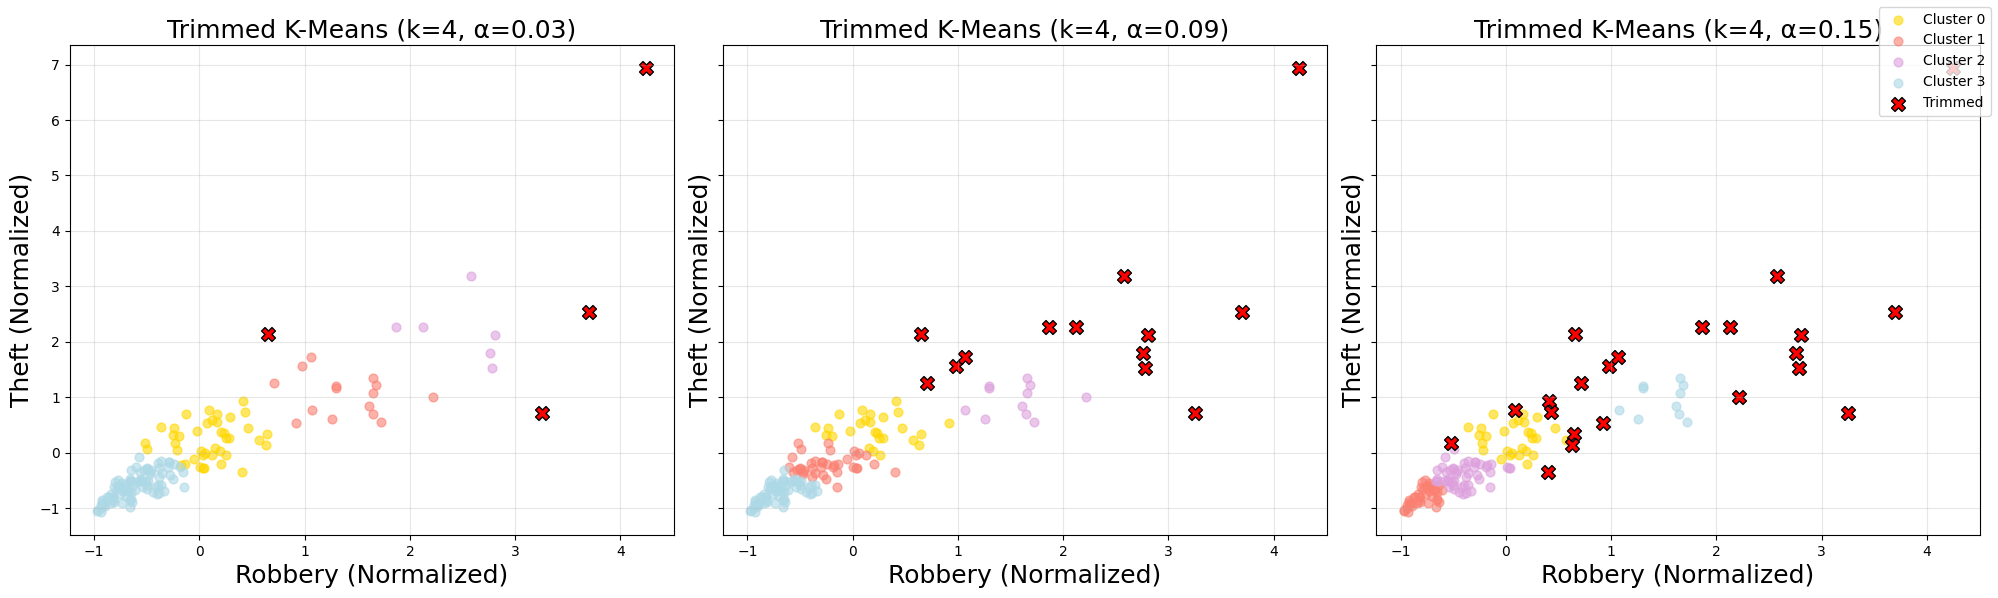

In [26]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances_argmin_min
import matplotlib.pyplot as plt
import random

# Load and normalize the data
df = pd.read_csv("Berlin_crimes.csv")

features = ['Robbery', 'Theft']

# Step 1: Group raw (unscaled) data by region
grouped = df.groupby(['District', 'Location'])[features].mean().reset_index()

# Step 2: Standardize only Robbery and Theft columns
scaler = StandardScaler()
grouped_scaled = grouped.copy()
grouped_scaled[features] = scaler.fit_transform(grouped[features])
grouped = grouped_scaled

# Step 3: Extract X for clustering
X = grouped_scaled[features].values

# --- Trimmed KMeans implementation ---
def trimmed_kmeans(X, n_clusters=3, alpha=0.1, n_init=20, max_iter=100):
    best_inertia = np.inf
    best_centroids = None
    best_labels = None
    best_trimmed_idx = None

    n_trim = int(alpha * len(X))

    for _ in range(n_init):
        centroids = X[np.random.choice(len(X), n_clusters, replace=False)]
        for _ in range(max_iter):
            labels, distances = pairwise_distances_argmin_min(X, centroids)
            sorted_idx = np.argsort(distances)
            keep_idx = sorted_idx[:-n_trim]

            new_centroids = []
            for k in range(n_clusters):
                members = X[keep_idx][labels[keep_idx] == k]
                if len(members) > 0:
                    new_centroids.append(members.mean(axis=0))
                else:
                    new_centroids.append(X[np.random.choice(len(X))])
            centroids = np.vstack(new_centroids)

        labels, distances = pairwise_distances_argmin_min(X, centroids)
        trimmed_inertia = np.sum(np.sort(distances)[:-n_trim]**2)
        if trimmed_inertia < best_inertia:
            best_inertia = trimmed_inertia
            best_centroids = centroids
            best_labels = labels
            best_trimmed_idx = sorted_idx[-n_trim:]

    # Assign -1 to trimmed outliers
    best_labels[best_trimmed_idx] = -1

    return best_labels, best_trimmed_idx, best_centroids

# -----------------------------
# Generate plots for k=4 with α=0.03, 0.09, 0.15
# -----------------------------
alphas = [0.03, 0.09, 0.15]
k = 4
colors = ['gold', 'salmon', 'plum', 'lightblue']

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True, sharey=True)

for ax, alpha in zip(axes, alphas):
    labels_km, trimmed_km, _ = trimmed_kmeans(X, n_clusters=k, alpha=alpha)

    df_plot = grouped.copy()
    df_plot['Cluster'] = labels_km
    df_plot['Trimmed'] = False
    df_plot.loc[trimmed_km, 'Trimmed'] = True

    # Plot untrimmed clusters
    for c in range(k):
        subset = df_plot[(df_plot['Cluster'] == c) & (~df_plot['Trimmed'])]
        ax.scatter(subset['Robbery'], subset['Theft'], 
                   label=f"Cluster {c}", alpha=0.6, s=40, color=colors[c])

    # Plot trimmed points
    trimmed_subset = df_plot[df_plot['Trimmed']]
    ax.scatter(trimmed_subset['Robbery'], trimmed_subset['Theft'],
               color='red', marker='X', s=100, label='Trimmed', edgecolor='k')

    ax.set_title(f"Trimmed K-Means (k={k}, α={alpha})", fontsize=18)
    ax.set_xlabel("Robbery (Normalized)",fontsize=18)
    ax.set_ylabel("Theft (Normalized)",fontsize=18)
    ax.grid(alpha=0.3)

# Common legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.savefig("trimmed_kmeans_k4_alphas.png", dpi=300)
plt.show()
